# TCRB Finetuning Entrypoint Notebook

This notebook is a practical entrypoint for the finetuning workflow in this repository.

You can run it locally or on Colab/Kaggle GPU. It does three core things:
1. Builds finetuning datasets from benchmark traces (`tcrb finetune-data`)
2. Summarizes dataset quality so you can judge whether training data is usable
3. Computes base-vs-finetuned delta metrics (`tcrb eval-delta`) and explains what they mean

In [21]:
!nvidia-smi

Thu Apr  2 16:10:29 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   62C    P0             28W /   70W |    3699MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
from __future__ import annotations

import json
import os
import shutil
import subprocess
from collections import Counter
from pathlib import Path


REPO_NAME = 'tool-calling-reliability-benchmark'
REPO_URL = 'https://github.com/aaliyan1230/tool-calling-reliability-benchmark.git'


def find_repo_root(start: Path) -> Path | None:
    for candidate in [start, *start.parents]:
        if (candidate / 'pyproject.toml').exists() and (candidate / 'src').exists():
            return candidate
    return None


repo_root = find_repo_root(Path.cwd())
if repo_root is None:
    kaggle_repo = Path('/kaggle/working') / REPO_NAME
    if not kaggle_repo.exists():
        print(f'[setup] Cloning repo to {kaggle_repo} ...')
        subprocess.run(['git', 'clone', REPO_URL, str(kaggle_repo)], check=True)
    repo_root = kaggle_repo

REPO_ROOT = repo_root.resolve()
os.chdir(REPO_ROOT)

if shutil.which('uv') is None:
    print('[setup] uv not found; installing uv...')
    subprocess.run(['python', '-m', 'pip', 'install', '-q', 'uv'], check=True)

print('Repo root:', REPO_ROOT)
print('Kernel cwd:', Path.cwd())

Repo root: /kaggle/working/tool-calling-reliability-benchmark
Kernel cwd: /kaggle/working/tool-calling-reliability-benchmark
.env loaded: False
HF_TOKEN set: True
Kaggle auth set: False


## 1) Pick Source Runs and Build Finetune Data

The command below converts benchmark attempt traces into training/eval JSONL.

By default, this notebook can merge multiple `runs/*/result.json` files to increase data coverage before splitting.

In [9]:
import random

VALIDATION_SPLIT = 0.25
MIN_EVAL_PER_POLICY = 1
USE_MULTI_SOURCE_DATA = True
MAX_SOURCE_RESULTS = 8
ALLOW_FINETUNED_SOURCES = False
ALLOW_OPEN_WORKLOAD_SOURCES = False

OUTPUT_DIR = REPO_ROOT / 'finetuned-models' / 'training-notebook'
WORKLOAD_PATH = REPO_ROOT / 'workloads' / 'sample_tasks.json'

preferred_sources = [
    REPO_ROOT / 'runs' / 'smoke-baseline' / 'result.json',
    REPO_ROOT / 'runs' / 'run-policy-native-sanity' / 'result.json',
]

all_result_files = list((REPO_ROOT / 'runs').glob('*/result.json'))

def source_allowed(path: Path) -> bool:
    name = path.parent.name.lower()
    if not ALLOW_FINETUNED_SOURCES and ('finetuned' in name or '-ft-' in name or name.startswith('ft-')):
        return False
    if not ALLOW_OPEN_WORKLOAD_SOURCES and ('-open-' in name or name.startswith('open-')):
        return False
    return True

def source_priority(path: Path) -> tuple[int, float]:
    # Higher rank first. Prefer baseline/native/smoke traces and de-prioritize notebook-generated base runs.
    name = path.parent.name.lower()
    rank = 0
    if 'smoke-baseline' in name:
        rank += 100
    if 'native' in name:
        rank += 60
    if 'baseline' in name:
        rank += 50
    if 'smoke' in name:
        rank += 25
    if 'sanity' in name:
        rank += 15

    if 'kaggle-notebook-base' in name:
        rank -= 35
    if 'kaggle-notebook' in name:
        rank -= 10

    mtime = path.stat().st_mtime if path.exists() else 0.0
    return (rank, mtime)

filtered_result_files = [p for p in all_result_files if source_allowed(p)]
filtered_result_files = sorted(filtered_result_files, key=source_priority, reverse=True)

# Prioritize preferred files, then fill from ranked artifacts.
ordered_sources = []
seen = set()
for p in [*preferred_sources, *filtered_result_files]:
    if p.exists() and p not in seen:
        ordered_sources.append(p)
        seen.add(p)

selected_sources = ordered_sources[:MAX_SOURCE_RESULTS] if USE_MULTI_SOURCE_DATA else ordered_sources[:1]

if not selected_sources:
    print('[data] No existing result.json found, running a baseline benchmark first...')
    gen_label = 'kaggle-notebook-baseline'
    gen_cmd = [
        'uv', 'run', 'tcrb', 'run',
        '--config', str(REPO_ROOT / 'configs' / 'baseline.json'),
        '--workload', str(WORKLOAD_PATH),
        '--label', gen_label,
    ]
    print('Running:', ' '.join(gen_cmd))
    gen_completed = subprocess.run(gen_cmd, text=True, capture_output=True, check=False)
    print(gen_completed.stdout)
    if gen_completed.returncode != 0:
        print(gen_completed.stderr)
        raise RuntimeError(f'baseline generation failed with code {gen_completed.returncode}')
    selected_sources = [REPO_ROOT / 'runs' / gen_label / 'result.json']

print('[data] Selected source artifacts:')
for p in selected_sources:
    print(' -', p)

def merge_result_payloads(result_paths: list[Path], out_path: Path) -> Path:
    merged_task_results = []
    source_rows = []
    for p in result_paths:
        payload = json.loads(p.read_text(encoding='utf-8'))
        rows = payload.get('task_results', [])
        merged_task_results.extend(rows)
        source_rows.append({'path': str(p), 'task_results': len(rows)})

    merged = {
        'generated_by': 'finetuning_entrypoint_notebook',
        'source_result_files': source_rows,
        'task_results': merged_task_results,
    }
    out_path.parent.mkdir(parents=True, exist_ok=True)
    out_path.write_text(json.dumps(merged, indent=2), encoding='utf-8')
    return out_path

if len(selected_sources) > 1:
    INPUT_RESULT_JSON = merge_result_payloads(
        selected_sources,
        OUTPUT_DIR / 'merged_input_result.json',
    )
    print('[data] Merged input JSON:', INPUT_RESULT_JSON)
else:
    INPUT_RESULT_JSON = selected_sources[0]

cmd = [
    'uv', 'run', 'tcrb', 'finetune-data',
    '--input-json', str(INPUT_RESULT_JSON),
    '--output-dir', str(OUTPUT_DIR),
    '--validation-split', str(VALIDATION_SPLIT),
    '--seed', '42',
    '--workload', str(WORKLOAD_PATH),
]

print('Running:', ' '.join(cmd))
completed = subprocess.run(cmd, text=True, capture_output=True, check=False)
if completed.returncode == 0:
    print(completed.stdout)
else:
    print('[data] CLI finetune-data unavailable, using notebook fallback builder...')
    payload = json.loads(INPUT_RESULT_JSON.read_text(encoding='utf-8'))

    with WORKLOAD_PATH.open('r', encoding='utf-8') as f:
        workload_payload = json.load(f)

    task_lookup = {
        t['task_id']: {
            'primary_tool': t['primary_tool'],
            'fallback_tools': list(t.get('fallback_tools', [])),
            'required_schema': list(t.get('required_schema', [])),
        }
        for t in workload_payload.get('tasks', [])
    }

    examples = []
    for row in payload.get('task_results', []):
        task_id = str(row.get('task_id', ''))
        policy = str(row.get('policy', ''))
        planner_id = str(row.get('planner_id', ''))
        attempted_before = []
        last_status = None
        for attempt in row.get('attempts', []):
            status = str(attempt.get('status', ''))
            tool_name = str(attempt.get('tool_name', '')).strip()
            invalid_tool_call = bool(attempt.get('invalid_tool_call', False))
            if status != 'success' or invalid_tool_call or not tool_name:
                attempted_before.append(tool_name)
                last_status = status
                continue

            prompt = {
                'task_id': task_id,
                'policy': policy,
                'planner_id': planner_id,
                'attempt_number': int(attempt.get('attempt_number', 0)),
                'attempted_tools': [x for x in attempted_before if x],
                'last_status': last_status,
            }
            prompt.update(task_lookup.get(task_id, {}))
            examples.append({'prompt': prompt, 'completion': {'tool_name': tool_name}})
            attempted_before.append(tool_name)
            last_status = status

    # Deduplicate
    seen = set()
    deduped = []
    for ex in examples:
        fp = json.dumps(ex, sort_keys=True)
        if fp in seen:
            continue
        seen.add(fp)
        deduped.append(ex)

    # Stratified split to keep policy coverage in eval on small datasets.
    by_policy = {}
    for ex in deduped:
        policy = str(ex.get('prompt', {}).get('policy', 'unknown'))
        by_policy.setdefault(policy, []).append(ex)

    rng = random.Random(42)
    train_rows = []
    eval_rows = []

    for policy, rows in by_policy.items():
        rows_copy = list(rows)
        rng.shuffle(rows_copy)
        desired_eval = int(round(len(rows_copy) * float(VALIDATION_SPLIT)))
        eval_count = max(MIN_EVAL_PER_POLICY, desired_eval) if len(rows_copy) > 1 else 0
        eval_count = min(eval_count, max(0, len(rows_copy) - 1))
        eval_rows.extend(rows_copy[:eval_count])
        train_rows.extend(rows_copy[eval_count:])

    rng.shuffle(train_rows)
    rng.shuffle(eval_rows)

    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    TRAIN_JSONL = OUTPUT_DIR / 'train_dataset.jsonl'
    EVAL_JSONL = OUTPUT_DIR / 'eval_dataset.jsonl'
    with TRAIN_JSONL.open('w', encoding='utf-8') as f:
        for row in train_rows:
            f.write(json.dumps(row, sort_keys=True) + '\n')
    with EVAL_JSONL.open('w', encoding='utf-8') as f:
        for row in eval_rows:
            f.write(json.dumps(row, sort_keys=True) + '\n')

    print(f'[data] Fallback build complete: total={len(deduped)} train={len(train_rows)} eval={len(eval_rows)} split={VALIDATION_SPLIT:.2f}')
    print('[data] Policy eval coverage:', sorted({str(r.get('prompt', {}).get('policy', 'unknown')) for r in eval_rows}))

TRAIN_JSONL = OUTPUT_DIR / 'train_dataset.jsonl'
EVAL_JSONL = OUTPUT_DIR / 'eval_dataset.jsonl'
print('Source result JSON:', INPUT_RESULT_JSON)
print('Train JSONL:', TRAIN_JSONL)
print('Eval JSONL:', EVAL_JSONL)

[data] No existing result.json found, running a baseline benchmark first...
Running: uv run tcrb run --config /kaggle/working/tool-calling-reliability-benchmark/configs/baseline.json --workload /kaggle/working/tool-calling-reliability-benchmark/workloads/sample_tasks.json --label kaggle-notebook-baseline
Planner: policy_native
Wrote benchmark results: runs/kaggle-notebook-baseline/result.json
Wrote markdown summary: runs/kaggle-notebook-baseline/summary.md

[data] Selected source artifacts:
 - /kaggle/working/tool-calling-reliability-benchmark/runs/kaggle-notebook-baseline/result.json
Running: uv run tcrb finetune-data --input-json /kaggle/working/tool-calling-reliability-benchmark/runs/kaggle-notebook-baseline/result.json --output-dir /kaggle/working/tool-calling-reliability-benchmark/finetuned-models/training-notebook --validation-split 0.25 --seed 42 --workload /kaggle/working/tool-calling-reliability-benchmark/workloads/sample_tasks.json
Examples total: 14
Train examples: 10
Eval e

In [10]:
SYNTH_TIMEOUT_DATA = True
MAX_TIMEOUT_SYNTH_PER_ROW = 2
SYNTH_TIMEOUT_SCENARIO_MULTIPLIER = 2

SYNTH_DIR = OUTPUT_DIR / 'synthetic'
SYNTH_TRAIN_JSONL = SYNTH_DIR / 'train_dataset_timeout_synth.jsonl'

def _load_jsonl_rows(path: Path) -> list[dict]:
    with path.open('r', encoding='utf-8') as f:
        return [json.loads(line) for line in f if line.strip()]

def _write_jsonl_rows(path: Path, rows: list[dict]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open('w', encoding='utf-8') as f:
        for row in rows:
            f.write(json.dumps(row, sort_keys=True) + '\n')

def _workload_maps(payload: dict) -> tuple[dict, dict]:
    tasks = {str(t.get('task_id', '')): t for t in payload.get('tasks', [])}
    tools = {str(t.get('name', '')): t for t in payload.get('tools', [])}
    return tasks, tools

def _ordered_tools(task: dict) -> list[str]:
    primary = str(task.get('primary_tool', ''))
    fallbacks = [str(x) for x in task.get('fallback_tools', [])]
    return [x for x in [primary, *fallbacks] if x]

def _min_latency_schema_tool_from_task(task: dict, tools_lookup: dict) -> str | None:
    required = set(task.get('required_schema', []))
    ordered = [name for name in _ordered_tools(task) if name in tools_lookup]
    if not ordered:
        return None

    compatible = []
    for name in ordered:
        schema_fields = set(tools_lookup[name].get('schema_fields', []))
        if required.issubset(schema_fields):
            compatible.append(name)

    if compatible:
        compatible.sort(key=lambda n: float(tools_lookup[n].get('base_latency_ms', 1e9)))
        return compatible[0]
    return ordered[0]

def _teacher_prompt_from_task(task: dict, attempted_tools: list[str], last_status: str | None) -> dict:
    return {
        'task_id': str(task.get('task_id', '')),
        'policy': 'timeout_budget_early_abort',
        'planner_id': 'synthetic_timeout_teacher',
        'attempt_number': 1 + len([x for x in attempted_tools if x]),
        'attempted_tools': [x for x in attempted_tools if x],
        'last_status': last_status,
        'primary_tool': str(task.get('primary_tool', '')),
        'fallback_tools': [str(x) for x in task.get('fallback_tools', [])],
        'required_schema': [str(x) for x in task.get('required_schema', [])],
        'synthesized_label': 'timeout_latency_teacher',
    }

if SYNTH_TIMEOUT_DATA and TRAIN_JSONL.exists() and WORKLOAD_PATH.exists():
    train_rows = _load_jsonl_rows(TRAIN_JSONL)
    workload_payload = json.loads(WORKLOAD_PATH.read_text(encoding='utf-8'))
    tasks_lookup, tools_lookup = _workload_maps(workload_payload)

    synth_rows = []

    # 1) Correct existing timeout rows toward latency-optimal schema-compatible teacher labels.
    for row in train_rows:
        prompt = dict(row.get('prompt', {}))
        completion = dict(row.get('completion', {}))
        if str(prompt.get('policy', '')) != 'timeout_budget_early_abort':
            continue

        task = tasks_lookup.get(str(prompt.get('task_id', '')))
        if task is None:
            continue

        target_tool = _min_latency_schema_tool_from_task(task, tools_lookup)
        current_tool = str(completion.get('tool_name', ''))
        if not target_tool or target_tool == current_tool:
            continue

        for _ in range(max(1, int(MAX_TIMEOUT_SYNTH_PER_ROW))):
            synth_prompt = dict(prompt)
            synth_prompt['synthesized_label'] = 'timeout_latency_teacher'
            synth_rows.append({'prompt': synth_prompt, 'completion': {'tool_name': target_tool}})

    # 2) Add scenario-based timeout examples directly from workload definitions.
    scenario_templates = [
        ([], None),
        (["{primary}"], 'timeout'),
        (["{primary}"], 'rate_limit'),
        (["{primary}"], 'network_failure'),
    ]

    for task in workload_payload.get('tasks', []):
        target_tool = _min_latency_schema_tool_from_task(task, tools_lookup)
        if not target_tool:
            continue

        primary = str(task.get('primary_tool', ''))
        for attempted_template, status in scenario_templates:
            attempted = [x.format(primary=primary) for x in attempted_template]
            prompt = _teacher_prompt_from_task(task, attempted_tools=attempted, last_status=status)
            for _ in range(max(1, int(SYNTH_TIMEOUT_SCENARIO_MULTIPLIER))):
                synth_rows.append({'prompt': prompt, 'completion': {'tool_name': target_tool}})

    # Deduplicate
    seen = set()
    deduped_synth = []
    for row in synth_rows:
        fp = json.dumps(row, sort_keys=True)
        if fp in seen:
            continue
        seen.add(fp)
        deduped_synth.append(row)

    augmented = train_rows + deduped_synth
    _write_jsonl_rows(SYNTH_TRAIN_JSONL, augmented)

    if deduped_synth:
        TRAIN_JSONL = SYNTH_TRAIN_JSONL
        print('[synth] Timeout label synthesis enabled.')
        print('[synth] Added synthetic rows:', len(deduped_synth))
        print('[synth] New TRAIN_JSONL:', TRAIN_JSONL)
    else:
        print('[synth] No timeout synthesis rows generated; keeping original TRAIN_JSONL.')
else:
    print('[synth] Skipped timeout synthesis.')
    print('[synth] SYNTH_TIMEOUT_DATA:', SYNTH_TIMEOUT_DATA)
    print('[synth] TRAIN_JSONL exists:', TRAIN_JSONL.exists() if isinstance(TRAIN_JSONL, Path) else False)
    print('[synth] WORKLOAD_PATH exists:', WORKLOAD_PATH.exists() if isinstance(WORKLOAD_PATH, Path) else False)

[synth] Timeout label synthesis enabled.
[synth] Added synthetic rows: 24
[synth] New TRAIN_JSONL: /kaggle/working/tool-calling-reliability-benchmark/finetuned-models/training-notebook/synthetic/train_dataset_timeout_synth.jsonl


## 1.5) Timeout-Policy Label Synthesis (Objective Alignment)

This step creates additional training rows for `timeout_budget_early_abort` where the completion is the lowest-latency schema-compatible tool. It addresses the mismatch between historical success traces and timeout policy intent.

- Reads current train JSONL
- Synthesizes timeout-policy rows with latency-optimal labels
- Writes a new training file and auto-switches `TRAIN_JSONL` to it

## 2) Inspect Dataset Quality

These numbers tell you if training data is healthy:
- More examples is generally better
- Tool label distribution should not be extremely collapsed
- Attempt-number and policy spread should look plausible

In [41]:
def load_jsonl(path: Path):
    with path.open('r', encoding='utf-8') as f:
        return [json.loads(line) for line in f if line.strip()]

train_rows = load_jsonl(TRAIN_JSONL)
eval_rows = load_jsonl(EVAL_JSONL)
all_rows = train_rows + eval_rows

tool_counts = Counter(row['completion']['tool_name'] for row in all_rows)
policy_counts = Counter(row['prompt'].get('policy', 'unknown') for row in all_rows)
attempt_counts = Counter(row['prompt'].get('attempt_number', 0) for row in all_rows)

print('Total examples:', len(all_rows))
print('Train examples:', len(train_rows))
print('Eval examples:', len(eval_rows))
print('Unique tools:', len(tool_counts))
print('Tool distribution:', dict(tool_counts))
print('Policy distribution:', dict(policy_counts))
print('Attempt-number distribution:', dict(attempt_counts))

Total examples: 53
Train examples: 46
Eval examples: 7
Unique tools: 5
Tool distribution: {'search_docs_v1': 22, 'voice_lookup_stream': 12, 'voice_lookup_batch': 7, 'extract_entities_ocr': 2, 'extract_entities_llm': 10}
Policy distribution: {'timeout_budget_early_abort': 31, 'naive_retry': 6, 'schema_first_fallback': 12, 'exponential_backoff_jitter': 4}
Attempt-number distribution: {1: 27, 2: 20, 3: 6}


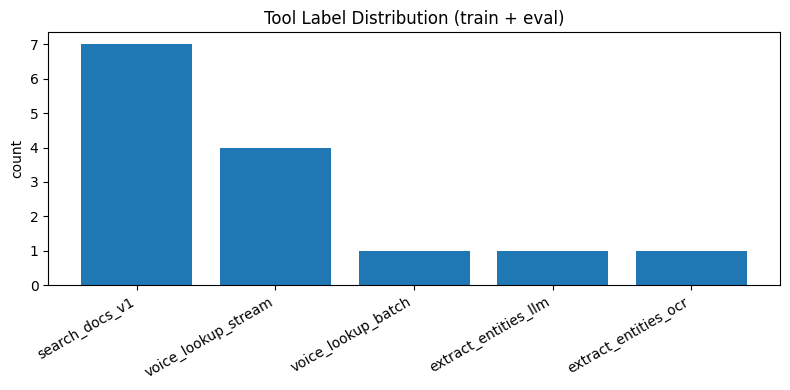

In [15]:
import matplotlib.pyplot as plt

labels = list(tool_counts.keys())
values = [tool_counts[k] for k in labels]

plt.figure(figsize=(8, 4))
plt.bar(labels, values)
plt.title('Tool Label Distribution (train + eval)')
plt.ylabel('count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 2.5) Policy-Rebalanced Training Set (Optional)

This step upweights examples from policies that are currently failing the gate so the next finetuning pass focuses on those failure modes.

- Reads current `delta.json` if present
- Picks policies with failing target checks
- Oversamples those policies in training JSONL
- Leaves eval set unchanged for consistency

In [42]:
import random

USE_REBALANCED_DATA = True
OVERSAMPLE_FACTOR = 3
MAX_BOOST_POLICIES = 1

DELTA_PATH_FOR_REBALANCE = REPO_ROOT / 'runs' / 'notebook-delta' / 'delta-ms.json'
if not DELTA_PATH_FOR_REBALANCE.exists():
    DELTA_PATH_FOR_REBALANCE = REPO_ROOT / 'runs' / 'notebook-delta' / 'delta.json'
REBALANCED_DIR = OUTPUT_DIR / 'rebalanced'
REBALANCED_TRAIN_JSONL = REBALANCED_DIR / 'train_dataset_rebalanced.jsonl'
REBALANCED_EVAL_JSONL = REBALANCED_DIR / 'eval_dataset_rebalanced.jsonl'


def load_jsonl_rows(path: Path) -> list[dict]:
    with path.open('r', encoding='utf-8') as f:
        return [json.loads(line) for line in f if line.strip()]


def failing_policies_from_delta(delta_path: Path, max_policies: int) -> list[str]:
    if not delta_path.exists():
        return []

    payload = json.loads(delta_path.read_text(encoding='utf-8'))
    target_rows = payload.get('target', {}).get('policies', [])

    ranked = []
    for row in target_rows:
        policy = str(row.get('policy', ''))
        if not policy:
            continue

        d = row.get('delta', {})
        success_delta = d.get('task_success_rate')
        invalid_delta = d.get('invalid_tool_call_rate')

        success_gap = 0.0 if success_delta is None else max(0.0, 0.02 - float(success_delta))
        invalid_gap = 0.0 if invalid_delta is None else max(0.0, float(invalid_delta) - 0.01)

        # Weight invalid-call regressions more strongly to preserve reliability.
        deficit = success_gap + (1.5 * invalid_gap)

        if deficit > 0.0:
            ranked.append((deficit, policy))

    ranked.sort(reverse=True)
    return [policy for _, policy in ranked[:max_policies]]


train_rows = load_jsonl_rows(TRAIN_JSONL)
eval_rows = load_jsonl_rows(EVAL_JSONL)

failed_policies = failing_policies_from_delta(DELTA_PATH_FOR_REBALANCE, MAX_BOOST_POLICIES)
if not failed_policies:
    # If no delta yet, target the current weakest policy by default.
    failed_policies = ['timeout_budget_early_abort']

boost = [r for r in train_rows if str(r.get('prompt', {}).get('policy', '')) in set(failed_policies)]

if USE_REBALANCED_DATA and boost:
    random.Random(42).shuffle(boost)
    augmented = train_rows + boost * max(1, int(OVERSAMPLE_FACTOR))
    random.Random(43).shuffle(augmented)

    REBALANCED_DIR.mkdir(parents=True, exist_ok=True)
    with REBALANCED_TRAIN_JSONL.open('w', encoding='utf-8') as f:
        for row in augmented:
            f.write(json.dumps(row, sort_keys=True) + '\n')
    with REBALANCED_EVAL_JSONL.open('w', encoding='utf-8') as f:
        for row in eval_rows:
            f.write(json.dumps(row, sort_keys=True) + '\n')

    print('Rebalanced training data written.')
    print('Delta source used:', DELTA_PATH_FOR_REBALANCE)
    print('Policies targeted:', failed_policies)
    print('Original train size:', len(train_rows))
    print('Boost pool size:', len(boost))
    print('Rebalanced train size:', len(augmented))
    print('Rebalanced train JSONL:', REBALANCED_TRAIN_JSONL)
    print('Rebalanced eval JSONL:', REBALANCED_EVAL_JSONL)
else:
    print('Rebalancing skipped or no matching rows to boost.')
    print('USE_REBALANCED_DATA:', USE_REBALANCED_DATA)
    print('Delta source used:', DELTA_PATH_FOR_REBALANCE)
    print('Policies targeted:', failed_policies)

Rebalanced training data written.
Delta source used: /kaggle/working/tool-calling-reliability-benchmark/runs/notebook-delta/delta-ms.json
Policies targeted: ['timeout_budget_early_abort']
Original train size: 46
Boost pool size: 31
Rebalanced train size: 139
Rebalanced train JSONL: /kaggle/working/tool-calling-reliability-benchmark/finetuned-models/training-notebook/rebalanced/train_dataset_rebalanced.jsonl
Rebalanced eval JSONL: /kaggle/working/tool-calling-reliability-benchmark/finetuned-models/training-notebook/rebalanced/eval_dataset_rebalanced.jsonl


## 3) Base vs Finetuned Delta Evaluation

If you already have base and finetuned run outputs, this cell computes deltas.

Expected files can be either:
- `result.json` (single run)
- `multi_seed.json` (recommended)

In [24]:
def discover_run_candidates(root: Path):
    multi_seed = sorted((root / 'runs').glob('*/multi_seed.json'))
    single_run = sorted((root / 'runs').glob('*/result.json'))
    return multi_seed, single_run


def score_path(path: Path, keywords: list[str]) -> int:
    name = path.parent.name.lower()
    return sum(1 for k in keywords if k in name)


multi_seed_candidates, single_run_candidates = discover_run_candidates(REPO_ROOT)

# Prefer multi-seed, then fallback to single-run result.json
all_candidates = multi_seed_candidates if multi_seed_candidates else single_run_candidates

if not all_candidates:
    print('No benchmark result artifacts found under runs/.')
    print('Run baseline/finetuned benchmark jobs first, then rerun this cell.')
else:
    base_keywords = ['base', 'baseline', 'native']
    ft_keywords = ['ft', 'finetuned', 'proper']

    ranked_base = sorted(all_candidates, key=lambda p: score_path(p, base_keywords), reverse=True)
    ranked_ft = sorted(all_candidates, key=lambda p: score_path(p, ft_keywords), reverse=True)

    suggested_base = ranked_base[0]
    suggested_ft = ranked_ft[0]

    # Avoid selecting the same file for both if possible.
    if suggested_base == suggested_ft and len(ranked_ft) > 1:
        suggested_ft = ranked_ft[1]

    print('Detected candidates:')
    for p in all_candidates[:10]:
        print(' -', p)

    BASE_RUN = suggested_base
    FINETUNED_RUN = suggested_ft
    DELTA_JSON = REPO_ROOT / 'runs' / 'notebook-delta' / 'delta.json'
    DELTA_MD = REPO_ROOT / 'runs' / 'notebook-delta' / 'delta.md'

    print('\nSuggested BASE_RUN:', BASE_RUN)
    print('Suggested FINETUNED_RUN:', FINETUNED_RUN)
    print('DELTA_JSON:', DELTA_JSON)
    print('DELTA_MD:', DELTA_MD)

    if BASE_RUN == FINETUNED_RUN:
        print('\nWarning: base and finetuned paths are identical. Update manually before running Cell 11.')

Detected candidates:
 - /kaggle/working/tool-calling-reliability-benchmark/runs/kaggle-notebook-baseline/result.json
 - /kaggle/working/tool-calling-reliability-benchmark/runs/kaggle-notebook-finetuned/result.json

Suggested BASE_RUN: /kaggle/working/tool-calling-reliability-benchmark/runs/kaggle-notebook-baseline/result.json
Suggested FINETUNED_RUN: /kaggle/working/tool-calling-reliability-benchmark/runs/kaggle-notebook-finetuned/result.json
DELTA_JSON: /kaggle/working/tool-calling-reliability-benchmark/runs/notebook-delta/delta.json
DELTA_MD: /kaggle/working/tool-calling-reliability-benchmark/runs/notebook-delta/delta.md


In [14]:
# Optional automation: generate fresh baseline + finetuned run artifacts for delta eval.
# This path uses local Hugging Face inference (no Ollama), with the same planner logic for base and finetuned.
import gc
import json
import sys
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

if str(REPO_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / 'src'))

from tcrb.benchmark import run_benchmark, write_result_json
from tcrb.config import load_benchmark_config, load_workload
from tcrb.reporting import write_markdown_summary

try:
    from peft import PeftModel
except Exception:
    PeftModel = None

AUTO_RUN_BENCHMARKS = True
FORCE_RERUN = True
AUTO_BASE_LABEL = 'kaggle-notebook-base-hf-local-v7'
AUTO_FT_LABEL = 'kaggle-notebook-finetuned-hf-local-v7'
AUTO_OPEN_BASE_LABEL = 'kaggle-notebook-base-hf-open-v7'
AUTO_OPEN_FT_LABEL = 'kaggle-notebook-finetuned-hf-open-v7'
AUTO_CONFIG = REPO_ROOT / 'configs' / 'baseline.json'
AUTO_WORKLOAD = REPO_ROOT / 'workloads' / 'sample_tasks.json'
AUTO_OPEN_WORKLOAD = REPO_ROOT / 'workloads' / 'open_toolchain_tasks.json'

HF_BASE_MODEL_ID = str(globals().get('MODEL_ID', 'Qwen/Qwen2.5-0.5B-Instruct'))
HF_TIMEOUT_NOTE = 'Local HF planner can take a few minutes for full benchmark runs.'

POLICY_HINTS = {
    'naive_retry': 'Prefer primary tool unless schema incompatibility is obvious.',
    'exponential_backoff_jitter': 'Prefer reliable schema-compatible tools and avoid repeated failing tools.',
    'schema_first_fallback': 'Strongly prefer schema-compatible fallback when schema-related failure occurred.',
    'timeout_budget_early_abort': 'Prefer lower-latency schema-compatible options under tight budget.',
}

STRICT_SCHEMA_POLICIES = {'schema_first_fallback', 'timeout_budget_early_abort'}


def build_open_workload(base_workload_path: Path, output_path: Path) -> Path:
    payload = json.loads(base_workload_path.read_text(encoding='utf-8'))
    mapped_tools = []
    name_map = {}

    for tool in payload.get('tools', []):
        old_name = str(tool.get('name', ''))
        new_name = f'open_{old_name}'
        name_map[old_name] = new_name

        tool_copy = dict(tool)
        tool_copy['name'] = new_name
        tool_copy['base_latency_ms'] = int(round(float(tool_copy.get('base_latency_ms', 300)) * 1.08))
        mapped_tools.append(tool_copy)

    mapped_tasks = []
    for task in payload.get('tasks', []):
        t = dict(task)
        t['task_id'] = f"open-{t.get('task_id', 'task')}"
        t['primary_tool'] = name_map.get(str(t.get('primary_tool', '')), str(t.get('primary_tool', '')))
        t['fallback_tools'] = [name_map.get(str(x), str(x)) for x in t.get('fallback_tools', [])]
        mapped_tasks.append(t)

    open_payload = {'tools': mapped_tools, 'tasks': mapped_tasks}
    output_path.parent.mkdir(parents=True, exist_ok=True)
    output_path.write_text(json.dumps(open_payload, indent=2), encoding='utf-8')
    return output_path


def resolve_adapter_path(repo_root: Path) -> Path | None:
    candidates = []

    output_dir = globals().get('OUTPUT_DIR')
    if isinstance(output_dir, Path):
        candidates.append(output_dir / 'adapter')

    artifact_dir_var = globals().get('artifact_dir')
    if isinstance(artifact_dir_var, Path):
        candidates.append(artifact_dir_var / 'adapter')

    candidates.append(repo_root / 'outputs' / 'ft-notebook' / 'final')
    candidates.extend(sorted((repo_root / 'finetuned-models').glob('**/adapter')))

    for candidate in candidates:
        if candidate.exists():
            return candidate
    return None


def supports_schema(tool_spec, task) -> bool:
    return all(field in tool_spec.schema_fields for field in task.required_schema)


def heuristic_pick(task, workload, attempted_tools: set[str], last_status: str | None) -> str:
    ordered = [task.primary_tool, *task.fallback_tools]
    ordered = [name for name in ordered if name in workload.tools]
    if not ordered:
        return ''

    schema_issue = str(last_status or '') in {'malformed_schema', 'contract_drift', 'invalid_schema', 'unknown_tool'}
    if schema_issue:
        for name in ordered:
            if name in attempted_tools:
                continue
            if supports_schema(workload.tools[name], task):
                return name

    for name in ordered:
        if supports_schema(workload.tools[name], task):
            return name

    return ordered[0]


class HFLocalPlanner:
    def __init__(self, *, planner_id: str, base_model_id: str, adapter_path: Path | None = None):
        self.planner_id = planner_id
        self.base_model_id = base_model_id
        self.adapter_path = adapter_path

        self.tokenizer = AutoTokenizer.from_pretrained(base_model_id, trust_remote_code=True)
        if self.tokenizer.pad_token_id is None and self.tokenizer.eos_token_id is not None:
            self.tokenizer.pad_token_id = self.tokenizer.eos_token_id

        model_kwargs = {'trust_remote_code': True}
        if torch.cuda.is_available():
            model_kwargs.update({'dtype': torch.float16, 'device_map': 'auto'})

        base_model = AutoModelForCausalLM.from_pretrained(base_model_id, **model_kwargs)
        if adapter_path is not None:
            if PeftModel is None:
                raise RuntimeError('peft is required to load adapter_path but is not available in this kernel.')
            self.model = PeftModel.from_pretrained(base_model, str(adapter_path))
        else:
            self.model = base_model

        self.model.eval()

    def _prompt(self, *, task, workload, policy: str, attempt_number: int, attempted_tools: set[str], last_status: str | None) -> str:
        ordered = [task.primary_tool, *task.fallback_tools]
        available = [name for name in ordered if name in workload.tools]
        tool_schemas = {
            name: {
                'schema_fields': workload.tools[name].schema_fields,
                'base_latency_ms': workload.tools[name].base_latency_ms,
            }
            for name in available
        }

        payload = {
            'task': {
                'task_id': task.task_id,
                'primary_tool': task.primary_tool,
                'fallback_tools': task.fallback_tools,
                'required_schema': task.required_schema,
            },
            'policy': policy,
            'policy_hint': POLICY_HINTS.get(policy, ''),
            'attempt_number': attempt_number,
            'attempted_tools': sorted(attempted_tools),
            'last_status': last_status,
            'available_tools': available,
            'tool_schemas': tool_schemas,
        }
        return (
            'Select exactly one tool for this task. '
            'Output must be valid JSON with key tool_name only.\n\n'
            + json.dumps(payload, ensure_ascii=True)
            + '\n\nJSON:'
        )

    def _sequence_logprob(self, prompt: str, completion: str) -> float:
        full_text = prompt + completion
        enc_full = self.tokenizer(full_text, return_tensors='pt')
        enc_prompt = self.tokenizer(prompt, return_tensors='pt')

        input_ids = enc_full['input_ids']
        attention_mask = enc_full['attention_mask']
        prompt_len = int(enc_prompt['input_ids'].shape[1])

        if torch.cuda.is_available():
            input_ids = input_ids.to(self.model.device)
            attention_mask = attention_mask.to(self.model.device)

        with torch.inference_mode():
            logits = self.model(input_ids=input_ids, attention_mask=attention_mask).logits

        shifted_logits = logits[:, :-1, :]
        shifted_targets = input_ids[:, 1:]

        start = max(0, prompt_len - 1)
        token_log_probs = torch.log_softmax(shifted_logits[:, start:, :], dim=-1)
        target_slice = shifted_targets[:, start:]

        gathered = token_log_probs.gather(dim=-1, index=target_slice.unsqueeze(-1)).squeeze(-1)
        return float(gathered.sum().item())

    def _policy_adjustment(self, *, name: str, task, workload, policy: str, attempted_tools: set[str], last_status: str | None) -> float:
        schema_ok = supports_schema(workload.tools[name], task)
        schema_issue = str(last_status or '') in {'malformed_schema', 'contract_drift', 'invalid_schema', 'unknown_tool'}

        score = 0.0
        if schema_ok:
            score += 0.35
        else:
            # Soft schema penalty for non-strict policies to preserve adaptation signal.
            score -= 0.20

        if schema_issue and name in attempted_tools:
            score -= 0.60

        if policy == 'schema_first_fallback':
            # Only prefer fallback after a schema-related failure; otherwise keep primary bias.
            if schema_issue and schema_ok and name != task.primary_tool:
                score += 0.25
            if (not schema_issue) and name == task.primary_tool:
                score += 0.20
        if policy == 'timeout_budget_early_abort':
            latency = float(workload.tools[name].base_latency_ms)
            score += max(-0.25, (450.0 - latency) / 1500.0)
        if policy == 'naive_retry' and name == task.primary_tool:
            score += 0.10

        return score

    def choose_tool(self, *, task, workload, policy, attempt_number, attempted_tools, last_status, rng):
        del rng

        if policy in {'schema_first_fallback', 'timeout_budget_early_abort'}:
            # Reliability guardrail: deterministic schema-aware routing for sensitive policies.
            return heuristic_pick(task, workload, attempted_tools, last_status)

        prompt = self._prompt(
            task=task,
            workload=workload,
            policy=policy,
            attempt_number=attempt_number,
            attempted_tools=attempted_tools,
            last_status=last_status,
        )

        candidates = [task.primary_tool, *task.fallback_tools]
        candidates = [name for name in candidates if name in workload.tools]
        if not candidates:
            return ''

        scored = []
        for name in candidates:
            completion = json.dumps({'tool_name': name}, ensure_ascii=True)
            model_score = self._sequence_logprob(prompt, completion)
            adjusted = model_score + self._policy_adjustment(
                name=name,
                task=task,
                workload=workload,
                policy=policy,
                attempted_tools=attempted_tools,
                last_status=last_status,
            )
            scored.append((adjusted, name))

        scored.sort(reverse=True)

        if policy in STRICT_SCHEMA_POLICIES:
            # Hard guard only for schema-sensitive policies.
            for _, name in scored:
                if supports_schema(workload.tools[name], task):
                    return name

        # For other policies, best adjusted score wins (with soft schema penalty already applied).
        if scored:
            return scored[0][1]

        return heuristic_pick(task, workload, attempted_tools, last_status)


def run_benchmark_with_planner(label: str, planner, workload_path: Path) -> Path:
    run_dir = REPO_ROOT / 'runs' / label
    result_json = run_dir / 'result.json'
    summary_md = run_dir / 'summary.md'

    if result_json.exists() and not FORCE_RERUN:
        print(f'Skipping {label}: existing artifact found at {result_json}')
        return result_json

    workload = load_workload(workload_path)
    config = load_benchmark_config(AUTO_CONFIG)
    result = run_benchmark(workload=workload, config=config, planner=planner)

    write_result_json(result, result_json)
    write_markdown_summary(result, summary_md)
    print('Wrote:', result_json)
    print('Wrote:', summary_md)
    return result_json


if AUTO_RUN_BENCHMARKS:
    adapter_path = resolve_adapter_path(REPO_ROOT)
    if adapter_path is None:
        raise RuntimeError('No adapter found for finetuned run. Expected outputs/ft-notebook/final or finetuned-models/**/adapter')

    open_workload_path = build_open_workload(AUTO_WORKLOAD, AUTO_OPEN_WORKLOAD)

    print(HF_TIMEOUT_NOTE)
    print('Base model:', HF_BASE_MODEL_ID)
    print('Adapter path:', adapter_path)
    print('Open workload:', open_workload_path)

    base_planner = HFLocalPlanner(
        planner_id='hf-local-base',
        base_model_id=HF_BASE_MODEL_ID,
        adapter_path=None,
    )
    base_result = run_benchmark_with_planner(AUTO_BASE_LABEL, base_planner, AUTO_WORKLOAD)
    open_base_result = run_benchmark_with_planner(AUTO_OPEN_BASE_LABEL, base_planner, open_workload_path)
    del base_planner
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    ft_planner = HFLocalPlanner(
        planner_id='hf-local-finetuned',
        base_model_id=HF_BASE_MODEL_ID,
        adapter_path=adapter_path,
    )
    ft_result = run_benchmark_with_planner(AUTO_FT_LABEL, ft_planner, AUTO_WORKLOAD)
    open_ft_result = run_benchmark_with_planner(AUTO_OPEN_FT_LABEL, ft_planner, open_workload_path)
    del ft_planner
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    BASE_RUN = base_result
    FINETUNED_RUN = ft_result
    OPEN_BASE_RUN = open_base_result
    OPEN_FINETUNED_RUN = open_ft_result
    DELTA_JSON = REPO_ROOT / 'runs' / 'notebook-delta' / 'delta.json'
    DELTA_MD = REPO_ROOT / 'runs' / 'notebook-delta' / 'delta.md'

    print('\nAuto-set for delta eval:')
    print('BASE_RUN:', BASE_RUN)
    print('FINETUNED_RUN:', FINETUNED_RUN)
    print('OPEN_BASE_RUN:', OPEN_BASE_RUN)
    print('OPEN_FINETUNED_RUN:', OPEN_FINETUNED_RUN)
else:
    print('AUTO_RUN_BENCHMARKS is False; skipping automation.')

Local HF planner can take a few minutes for full benchmark runs.
Base model: Qwen/Qwen2.5-3B-Instruct
Adapter path: /kaggle/working/tool-calling-reliability-benchmark/outputs/ft-notebook/final
Open workload: /kaggle/working/tool-calling-reliability-benchmark/workloads/open_toolchain_tasks.json


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

Wrote: /kaggle/working/tool-calling-reliability-benchmark/runs/kaggle-notebook-base-hf-local-v7/result.json
Wrote: /kaggle/working/tool-calling-reliability-benchmark/runs/kaggle-notebook-base-hf-local-v7/summary.md
Wrote: /kaggle/working/tool-calling-reliability-benchmark/runs/kaggle-notebook-base-hf-open-v7/result.json
Wrote: /kaggle/working/tool-calling-reliability-benchmark/runs/kaggle-notebook-base-hf-open-v7/summary.md


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

Wrote: /kaggle/working/tool-calling-reliability-benchmark/runs/kaggle-notebook-finetuned-hf-local-v7/result.json
Wrote: /kaggle/working/tool-calling-reliability-benchmark/runs/kaggle-notebook-finetuned-hf-local-v7/summary.md
Wrote: /kaggle/working/tool-calling-reliability-benchmark/runs/kaggle-notebook-finetuned-hf-open-v7/result.json
Wrote: /kaggle/working/tool-calling-reliability-benchmark/runs/kaggle-notebook-finetuned-hf-open-v7/summary.md

Auto-set for delta eval:
BASE_RUN: /kaggle/working/tool-calling-reliability-benchmark/runs/kaggle-notebook-base-hf-local-v7/result.json
FINETUNED_RUN: /kaggle/working/tool-calling-reliability-benchmark/runs/kaggle-notebook-finetuned-hf-local-v7/result.json
OPEN_BASE_RUN: /kaggle/working/tool-calling-reliability-benchmark/runs/kaggle-notebook-base-hf-open-v7/result.json
OPEN_FINETUNED_RUN: /kaggle/working/tool-calling-reliability-benchmark/runs/kaggle-notebook-finetuned-hf-open-v7/result.json


In [18]:
from dataclasses import replace
from statistics import mean, pstdev

AUTO_RUN_MULTI_SEED = True
MULTI_SEED_VALUES = [11, 22, 33]
FORCE_RERUN_MULTI_SEED = True

AUTO_BASE_MULTI_LABEL = 'kaggle-notebook-base-hf-local-v7-ms3'
AUTO_FT_MULTI_LABEL = 'kaggle-notebook-finetuned-hf-local-v7-ms3'
AUTO_OPEN_BASE_MULTI_LABEL = 'kaggle-notebook-base-hf-open-v7-ms3'
AUTO_OPEN_FT_MULTI_LABEL = 'kaggle-notebook-finetuned-hf-open-v7-ms3'

MS_METRICS = [
    'task_success_rate',
    'invalid_tool_call_rate',
    'mean_latency_ms',
    'p95_latency_ms',
    'retries_per_successful_task',
    'estimated_cost_per_successful_task_usd',
]

def aggregate_multi_seed_payload(seed_payloads: list[dict], seeds: list[int]) -> dict:
    by_policy_metric = {}
    for payload in seed_payloads:
        for row in payload.get('policy_metrics', []):
            policy = str(row.get('policy', ''))
            if not policy:
                continue
            by_policy_metric.setdefault(policy, {m: [] for m in MS_METRICS})
            for metric in MS_METRICS:
                value = row.get(metric)
                if value is not None:
                    by_policy_metric[policy][metric].append(float(value))

    aggregate_rows = []
    for policy in sorted(by_policy_metric):
        metric_summary = {}
        for metric in MS_METRICS:
            values = by_policy_metric[policy].get(metric, [])
            if not values:
                metric_summary[metric] = {'mean': None, 'std': None, 'n': 0}
            else:
                metric_summary[metric] = {
                    'mean': float(mean(values)),
                    'std': float(pstdev(values)) if len(values) > 1 else 0.0,
                    'n': len(values),
                }
        aggregate_rows.append({'policy': policy, 'metrics': metric_summary})

    return {
        'type': 'multi_seed',
        'seeds': seeds,
        'aggregate_policy_metrics': aggregate_rows,
        'seed_runs': len(seed_payloads),
    }

def config_with_seed(config_obj, seed: int):
    seed = int(seed)
    # Handle frozen dataclasses used by this repo's benchmark config models.
    try:
        return replace(config_obj, seed=seed)
    except Exception:
        pass
    # Handle pydantic-style immutable models.
    if hasattr(config_obj, 'model_copy'):
        return config_obj.model_copy(update={'seed': seed})
    if hasattr(config_obj, 'copy'):
        try:
            return config_obj.copy(update={'seed': seed})
        except Exception:
            pass
    # Last resort for mutable objects.
    if hasattr(config_obj, 'seed'):
        try:
            config_obj.seed = seed
            return config_obj
        except Exception:
            pass
    return config_obj

def run_multi_seed_with_planner(label: str, planner, workload_path: Path, seeds: list[int]) -> Path:
    run_dir = REPO_ROOT / 'runs' / label
    run_dir.mkdir(parents=True, exist_ok=True)
    aggregate_path = run_dir / 'multi_seed.json'

    if aggregate_path.exists() and not FORCE_RERUN_MULTI_SEED:
        print(f'Skipping {label}: existing multi_seed artifact found at {aggregate_path}')
        return aggregate_path

    workload = load_workload(workload_path)
    seed_payloads = []

    for seed in seeds:
        base_config = load_benchmark_config(AUTO_CONFIG)
        config = config_with_seed(base_config, seed)

        result = run_benchmark(workload=workload, config=config, planner=planner)
        seed_json = run_dir / f'seed-{seed}.result.json'
        seed_md = run_dir / f'seed-{seed}.summary.md'
        write_result_json(result, seed_json)
        write_markdown_summary(result, seed_md)

        seed_payload = json.loads(seed_json.read_text(encoding='utf-8'))
        seed_payloads.append(seed_payload)
        print(f'Wrote seed {seed}: {seed_json}')

    aggregate_payload = aggregate_multi_seed_payload(seed_payloads, seeds)
    aggregate_path.write_text(json.dumps(aggregate_payload, indent=2), encoding='utf-8')
    print('Wrote aggregate multi_seed JSON:', aggregate_path)
    return aggregate_path

if AUTO_RUN_MULTI_SEED:
    adapter_path = resolve_adapter_path(REPO_ROOT)
    if adapter_path is None:
        raise RuntimeError('No adapter found for finetuned run. Expected outputs/ft-notebook/final or finetuned-models/**/adapter')

    open_workload_path = build_open_workload(AUTO_WORKLOAD, AUTO_OPEN_WORKLOAD)

    print('[multi-seed] Seeds:', MULTI_SEED_VALUES)
    print('[multi-seed] Base model:', HF_BASE_MODEL_ID)

    base_planner_ms = HFLocalPlanner(
        planner_id='hf-local-base-ms',
        base_model_id=HF_BASE_MODEL_ID,
        adapter_path=None,
    )
    base_multi = run_multi_seed_with_planner(AUTO_BASE_MULTI_LABEL, base_planner_ms, AUTO_WORKLOAD, MULTI_SEED_VALUES)
    open_base_multi = run_multi_seed_with_planner(AUTO_OPEN_BASE_MULTI_LABEL, base_planner_ms, open_workload_path, MULTI_SEED_VALUES)
    del base_planner_ms
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    ft_planner_ms = HFLocalPlanner(
        planner_id='hf-local-finetuned-ms',
        base_model_id=HF_BASE_MODEL_ID,
        adapter_path=adapter_path,
    )
    ft_multi = run_multi_seed_with_planner(AUTO_FT_MULTI_LABEL, ft_planner_ms, AUTO_WORKLOAD, MULTI_SEED_VALUES)
    open_ft_multi = run_multi_seed_with_planner(AUTO_OPEN_FT_MULTI_LABEL, ft_planner_ms, open_workload_path, MULTI_SEED_VALUES)
    del ft_planner_ms
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    BASE_RUN = base_multi
    FINETUNED_RUN = ft_multi
    OPEN_BASE_RUN = open_base_multi
    OPEN_FINETUNED_RUN = open_ft_multi

    DELTA_JSON = REPO_ROOT / 'runs' / 'notebook-delta' / 'delta-ms.json'
    DELTA_MD = REPO_ROOT / 'runs' / 'notebook-delta' / 'delta-ms.md'

    print('\nAuto-set for multi-seed delta eval:')
    print('BASE_RUN:', BASE_RUN)
    print('FINETUNED_RUN:', FINETUNED_RUN)
    print('OPEN_BASE_RUN:', OPEN_BASE_RUN)
    print('OPEN_FINETUNED_RUN:', OPEN_FINETUNED_RUN)
    print('DELTA_JSON:', DELTA_JSON)
    print('DELTA_MD:', DELTA_MD)
else:
    print('AUTO_RUN_MULTI_SEED is False; skipping multi-seed benchmark automation.')

[multi-seed] Seeds: [11, 22, 33]
[multi-seed] Base model: Qwen/Qwen2.5-3B-Instruct


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

Wrote seed 11: /kaggle/working/tool-calling-reliability-benchmark/runs/kaggle-notebook-base-hf-local-v7-ms3/seed-11.result.json
Wrote seed 22: /kaggle/working/tool-calling-reliability-benchmark/runs/kaggle-notebook-base-hf-local-v7-ms3/seed-22.result.json
Wrote seed 33: /kaggle/working/tool-calling-reliability-benchmark/runs/kaggle-notebook-base-hf-local-v7-ms3/seed-33.result.json
Wrote aggregate multi_seed JSON: /kaggle/working/tool-calling-reliability-benchmark/runs/kaggle-notebook-base-hf-local-v7-ms3/multi_seed.json
Wrote seed 11: /kaggle/working/tool-calling-reliability-benchmark/runs/kaggle-notebook-base-hf-open-v7-ms3/seed-11.result.json
Wrote seed 22: /kaggle/working/tool-calling-reliability-benchmark/runs/kaggle-notebook-base-hf-open-v7-ms3/seed-22.result.json
Wrote seed 33: /kaggle/working/tool-calling-reliability-benchmark/runs/kaggle-notebook-base-hf-open-v7-ms3/seed-33.result.json
Wrote aggregate multi_seed JSON: /kaggle/working/tool-calling-reliability-benchmark/runs/kagg

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

Wrote seed 11: /kaggle/working/tool-calling-reliability-benchmark/runs/kaggle-notebook-finetuned-hf-local-v7-ms3/seed-11.result.json
Wrote seed 22: /kaggle/working/tool-calling-reliability-benchmark/runs/kaggle-notebook-finetuned-hf-local-v7-ms3/seed-22.result.json
Wrote seed 33: /kaggle/working/tool-calling-reliability-benchmark/runs/kaggle-notebook-finetuned-hf-local-v7-ms3/seed-33.result.json
Wrote aggregate multi_seed JSON: /kaggle/working/tool-calling-reliability-benchmark/runs/kaggle-notebook-finetuned-hf-local-v7-ms3/multi_seed.json
Wrote seed 11: /kaggle/working/tool-calling-reliability-benchmark/runs/kaggle-notebook-finetuned-hf-open-v7-ms3/seed-11.result.json
Wrote seed 22: /kaggle/working/tool-calling-reliability-benchmark/runs/kaggle-notebook-finetuned-hf-open-v7-ms3/seed-22.result.json
Wrote seed 33: /kaggle/working/tool-calling-reliability-benchmark/runs/kaggle-notebook-finetuned-hf-open-v7-ms3/seed-33.result.json
Wrote aggregate multi_seed JSON: /kaggle/working/tool-call

## 3.5) Multi-Seed Aggregate Evaluation (Recommended)

Single-run deltas can be noisy on small workloads. This cell reruns base and finetuned planners across multiple seeds and writes `multi_seed.json` artifacts so gate decisions use aggregate means.

In [19]:
# If the discovery/automation cells set these vars, keep them. Otherwise use historical defaults.
BASE_RUN = globals().get(
    'BASE_RUN',
    REPO_ROOT / 'runs' / 'ms-next-qwen3-4b-s10' / 'multi_seed.json',
)
FINETUNED_RUN = globals().get(
    'FINETUNED_RUN',
    REPO_ROOT / 'runs' / 'ms-proper-qwen3-4b' / 'multi_seed.json',
)
OPEN_BASE_RUN = globals().get('OPEN_BASE_RUN', None)
OPEN_FINETUNED_RUN = globals().get('OPEN_FINETUNED_RUN', None)

DELTA_JSON = globals().get(
    'DELTA_JSON',
    REPO_ROOT / 'runs' / 'notebook-delta' / 'delta.json',
)
DELTA_MD = globals().get(
    'DELTA_MD',
    REPO_ROOT / 'runs' / 'notebook-delta' / 'delta.md',
)


METRIC_NAMES = [
    'task_success_rate',
    'invalid_tool_call_rate',
    'mean_latency_ms',
    'p95_latency_ms',
    'retries_per_successful_task',
    'estimated_cost_per_successful_task_usd',
]


def normalize_policy_metrics(payload: dict) -> dict[str, dict[str, float | None]]:
    if payload.get('type') == 'multi_seed':
        rows = payload.get('aggregate_policy_metrics', [])
        out = {}
        for row in rows:
            policy = str(row.get('policy', ''))
            metrics = row.get('metrics', {})
            out[policy] = {
                m: (
                    float(metrics.get(m, {}).get('mean'))
                    if metrics.get(m, {}).get('mean') is not None
                    else None
                )
                for m in METRIC_NAMES
            }
        return out

    rows = payload.get('policy_metrics', [])
    out = {}
    for row in rows:
        policy = str(row.get('policy', ''))
        out[policy] = {
            m: (float(row.get(m)) if row.get(m) is not None else None)
            for m in METRIC_NAMES
        }
    return out


def compare_payloads(base_payload: dict, finetuned_payload: dict) -> dict:
    base = normalize_policy_metrics(base_payload)
    ft = normalize_policy_metrics(finetuned_payload)

    policies = sorted(set(base.keys()) | set(ft.keys()))
    rows = []
    for policy in policies:
        b = base.get(policy, {})
        f = ft.get(policy, {})
        delta = {m: (None if (b.get(m) is None or f.get(m) is None) else float(f[m] - b[m])) for m in METRIC_NAMES}
        rows.append({'policy': policy, 'base': b, 'finetuned': f, 'delta': delta})

    return {'policies': rows}


def write_simple_delta_markdown(payload: dict, out_path: Path) -> None:
    lines = ['# Base vs Finetuned Delta', '', 'Delta = finetuned - base', '']

    def append_section(title: str, section_rows: list[dict]) -> None:
        lines.append(f'## {title}')
        if not section_rows:
            lines.append('No comparable policy rows found.')
            lines.append('')
            return
        for row in section_rows:
            lines.append(f"### {row.get('policy', 'unknown')}")
            lines.append('| Metric | Delta (ft - base) |')
            lines.append('|---|---:|')
            for metric, value in row.get('delta', {}).items():
                val = 'n/a' if value is None else f'{float(value):.6f}'
                lines.append(f'| {metric} | {val} |')
            lines.append('')

    append_section('Target workload', payload.get('target', {}).get('policies', []))
    if isinstance(payload.get('open'), dict):
        append_section('Open workload', payload.get('open', {}).get('policies', []))

    out_path.parent.mkdir(parents=True, exist_ok=True)
    out_path.write_text('\n'.join(lines), encoding='utf-8')


print('BASE_RUN:', BASE_RUN)
print('FINETUNED_RUN:', FINETUNED_RUN)
print('OPEN_BASE_RUN:', OPEN_BASE_RUN)
print('OPEN_FINETUNED_RUN:', OPEN_FINETUNED_RUN)

if not BASE_RUN.exists() or not FINETUNED_RUN.exists():
    print('Set BASE_RUN and FINETUNED_RUN to existing files before running delta eval.')
elif BASE_RUN == FINETUNED_RUN:
    print('BASE_RUN and FINETUNED_RUN are identical. Provide a real finetuned benchmark artifact.')
else:
    cmd = [
        'uv', 'run', 'tcrb', 'eval-delta',
        '--base-run', str(BASE_RUN),
        '--finetuned-run', str(FINETUNED_RUN),
        '--output-json', str(DELTA_JSON),
        '--output-report', str(DELTA_MD),
    ]

    have_open = (
        isinstance(OPEN_BASE_RUN, Path)
        and isinstance(OPEN_FINETUNED_RUN, Path)
        and OPEN_BASE_RUN.exists()
        and OPEN_FINETUNED_RUN.exists()
    )
    if have_open:
        cmd.extend(['--open-base-run', str(OPEN_BASE_RUN), '--open-finetuned-run', str(OPEN_FINETUNED_RUN)])

    print('Running:', ' '.join(cmd))
    completed = subprocess.run(cmd, text=True, capture_output=True, check=False)
    if completed.stdout:
        print(completed.stdout)

    if completed.returncode != 0:
        stderr = completed.stderr or ''
        print(stderr)
        if "invalid choice: 'eval-delta'" in stderr:
            print('eval-delta subcommand unavailable in this branch; using notebook fallback comparator.')
            base_payload = json.loads(BASE_RUN.read_text(encoding='utf-8'))
            ft_payload = json.loads(FINETUNED_RUN.read_text(encoding='utf-8'))
            delta_payload = {'target': compare_payloads(base_payload, ft_payload)}

            if have_open:
                open_base_payload = json.loads(OPEN_BASE_RUN.read_text(encoding='utf-8'))
                open_ft_payload = json.loads(OPEN_FINETUNED_RUN.read_text(encoding='utf-8'))
                delta_payload['open'] = compare_payloads(open_base_payload, open_ft_payload)

            DELTA_JSON.parent.mkdir(parents=True, exist_ok=True)
            DELTA_JSON.write_text(json.dumps(delta_payload, indent=2), encoding='utf-8')
            write_simple_delta_markdown(delta_payload, DELTA_MD)
            print('Delta JSON (fallback):', DELTA_JSON)
            print('Delta markdown report (fallback):', DELTA_MD)
        else:
            raise RuntimeError(f'eval-delta failed with code {completed.returncode}')
    else:
        print('Delta JSON:', DELTA_JSON)
        print('Delta markdown report:', DELTA_MD)

BASE_RUN: /kaggle/working/tool-calling-reliability-benchmark/runs/kaggle-notebook-base-hf-local-v7-ms3/multi_seed.json
FINETUNED_RUN: /kaggle/working/tool-calling-reliability-benchmark/runs/kaggle-notebook-finetuned-hf-local-v7-ms3/multi_seed.json
OPEN_BASE_RUN: /kaggle/working/tool-calling-reliability-benchmark/runs/kaggle-notebook-base-hf-open-v7-ms3/multi_seed.json
OPEN_FINETUNED_RUN: /kaggle/working/tool-calling-reliability-benchmark/runs/kaggle-notebook-finetuned-hf-open-v7-ms3/multi_seed.json
Running: uv run tcrb eval-delta --base-run /kaggle/working/tool-calling-reliability-benchmark/runs/kaggle-notebook-base-hf-local-v7-ms3/multi_seed.json --finetuned-run /kaggle/working/tool-calling-reliability-benchmark/runs/kaggle-notebook-finetuned-hf-local-v7-ms3/multi_seed.json --output-json /kaggle/working/tool-calling-reliability-benchmark/runs/notebook-delta/delta-ms.json --output-report /kaggle/working/tool-calling-reliability-benchmark/runs/notebook-delta/delta-ms.md --open-base-run 

In [21]:
def metric_direction_note(metric_name: str, value: float) -> str:
    higher_is_better = metric_name in {'task_success_rate'}
    lower_is_better = metric_name in {
        'invalid_tool_call_rate',
        'mean_latency_ms',
        'p95_latency_ms',
        'retries_per_successful_task',
        'estimated_cost_per_successful_task_usd',
    }
    if higher_is_better:
        return 'improved' if value > 0 else ('worse' if value < 0 else 'flat')
    if lower_is_better:
        return 'improved' if value < 0 else ('worse' if value > 0 else 'flat')
    return 'unknown'

if DELTA_JSON.exists():
    payload = json.loads(DELTA_JSON.read_text(encoding='utf-8'))
    target_rows = payload.get('target', {}).get('policies', [])
    print('Target workload interpretation')
    print('-' * 40)
    for row in target_rows:
        policy = row.get('policy', 'unknown')
        print(f'Policy: {policy}')
        for metric, value in row.get('delta', {}).items():
            if value is None:
                continue
            print(f'  {metric}: {value:.6f} ({metric_direction_note(metric, float(value))})')
        print()
else:
    print('No delta file yet. Run the previous cell after setting valid run paths.')

Target workload interpretation
----------------------------------------
Policy: exponential_backoff_jitter
  task_success_rate: 0.055556 (improved)
  invalid_tool_call_rate: -0.047619 (improved)
  mean_latency_ms: -4.444444 (improved)
  p95_latency_ms: -26.666667 (improved)
  retries_per_successful_task: -0.016667 (improved)
  estimated_cost_per_successful_task_usd: 0.000057 (worse)

Policy: naive_retry
  task_success_rate: 0.000000 (flat)
  invalid_tool_call_rate: 0.000000 (flat)
  mean_latency_ms: 0.000000 (flat)
  p95_latency_ms: 0.000000 (flat)
  retries_per_successful_task: 0.000000 (flat)
  estimated_cost_per_successful_task_usd: 0.000000 (flat)

Policy: schema_first_fallback
  task_success_rate: 0.000000 (flat)
  invalid_tool_call_rate: 0.000000 (flat)
  mean_latency_ms: 0.000000 (flat)
  p95_latency_ms: 0.000000 (flat)
  retries_per_successful_task: 0.000000 (flat)
  estimated_cost_per_successful_task_usd: 0.000000 (flat)

Policy: timeout_budget_early_abort
  task_success_rate:

In [22]:
from collections import Counter

def _load_result_payloads_for_taxonomy(path: Path) -> list[dict]:
    if not path.exists():
        return []
    payload = json.loads(path.read_text(encoding='utf-8'))
    if payload.get('type') == 'multi_seed':
        run_dir = path.parent
        seed_files = sorted(run_dir.glob('seed-*.result.json'))
        return [json.loads(p.read_text(encoding='utf-8')) for p in seed_files]
    return [payload]

def _workload_maps() -> tuple[dict, dict]:
    target_payload = json.loads((REPO_ROOT / 'workloads' / 'sample_tasks.json').read_text(encoding='utf-8'))
    open_path = REPO_ROOT / 'workloads' / 'open_toolchain_tasks.json'
    open_payload = json.loads(open_path.read_text(encoding='utf-8')) if open_path.exists() else {'tools': [], 'tasks': []}

    def maps(payload):
        tools = {str(t.get('name', '')): t for t in payload.get('tools', [])}
        tasks = {str(t.get('task_id', '')): t for t in payload.get('tasks', [])}
        return tools, tasks

    t_tools, t_tasks = maps(target_payload)
    o_tools, o_tasks = maps(open_payload)
    return ({'target': t_tools, 'open': o_tools}, {'target': t_tasks, 'open': o_tasks})

def _run_kind(task_id: str) -> str:
    return 'open' if str(task_id).startswith('open-') else 'target'

def timeout_taxonomy(result_path: Path) -> dict:
    payloads = _load_result_payloads_for_taxonomy(result_path)
    tools_by_kind, tasks_by_kind = _workload_maps()

    counts = Counter()
    status_counts = Counter()

    for payload in payloads:
        for tr in payload.get('task_results', []):
            if str(tr.get('policy', '')) != 'timeout_budget_early_abort':
                continue
            task_id = str(tr.get('task_id', ''))
            kind = _run_kind(task_id)
            task = tasks_by_kind.get(kind, {}).get(task_id, {})

            ordered = [str(task.get('primary_tool', ''))] + [str(x) for x in task.get('fallback_tools', [])]
            ordered = [x for x in ordered if x]
            required = set(task.get('required_schema', []))

            tools = tools_by_kind.get(kind, {})
            compatible = []
            for name in ordered:
                tool = tools.get(name)
                if not tool:
                    continue
                schema_fields = set(tool.get('schema_fields', []))
                if required.issubset(schema_fields):
                    compatible.append(name)

            if compatible:
                min_latency_tool = min(compatible, key=lambda n: float(tools[n].get('base_latency_ms', 1e9)))
            else:
                min_latency_tool = ordered[0] if ordered else None

            attempts = tr.get('attempts', [])
            counts['tasks_seen'] += 1
            counts['attempts_total'] += len(attempts)

            for a in attempts:
                status = str(a.get('status', ''))
                tool_name = str(a.get('tool_name', ''))
                invalid = bool(a.get('invalid_tool_call', False))

                status_counts[status] += 1
                if invalid:
                    counts['invalid_tool_call_attempts'] += 1

                if status == 'success' and tool_name:
                    counts['success_attempts'] += 1
                    if min_latency_tool and tool_name != min_latency_tool:
                        counts['success_non_min_latency_tool'] += 1

    return {
        'result_path': str(result_path),
        'counts': dict(counts),
        'status_counts': dict(status_counts),
    }

base_path = BASE_RUN if isinstance(BASE_RUN, Path) else Path(str(BASE_RUN))
ft_path = FINETUNED_RUN if isinstance(FINETUNED_RUN, Path) else Path(str(FINETUNED_RUN))

if base_path.exists() and ft_path.exists():
    base_tax = timeout_taxonomy(base_path)
    ft_tax = timeout_taxonomy(ft_path)
    print('=== Timeout Policy Taxonomy ===')
    print('BASE:', base_tax['result_path'])
    print('FT:  ', ft_tax['result_path'])
    print('\nBASE counts:', base_tax['counts'])
    print('FT counts:  ', ft_tax['counts'])
    print('\nBASE statuses:', base_tax['status_counts'])
    print('FT statuses:  ', ft_tax['status_counts'])
else:
    print('BASE_RUN/FINETUNED_RUN not set to existing files yet. Run benchmark cells first.')

=== Timeout Policy Taxonomy ===
BASE: /kaggle/working/tool-calling-reliability-benchmark/runs/kaggle-notebook-base-hf-local-v7-ms3/multi_seed.json
FT:   /kaggle/working/tool-calling-reliability-benchmark/runs/kaggle-notebook-finetuned-hf-local-v7-ms3/multi_seed.json

BASE counts: {'tasks_seen': 18, 'attempts_total': 22, 'success_attempts': 15, 'success_non_min_latency_tool': 3, 'invalid_tool_call_attempts': 2}
FT counts:   {'tasks_seen': 18, 'attempts_total': 22, 'success_attempts': 15, 'success_non_min_latency_tool': 3, 'invalid_tool_call_attempts': 2}

BASE statuses: {'success': 15, 'network_failure': 1, 'rate_limit': 1, 'timeout': 3, 'malformed_schema': 2}
FT statuses:   {'success': 15, 'network_failure': 1, 'rate_limit': 1, 'timeout': 3, 'malformed_schema': 2}


## 5.5) Timeout Policy Error Taxonomy (Pre-Gate Check)

Use this before final gating to inspect whether `timeout_budget_early_abort` failures are due to schema issues, wrong latency choices, or retries.

## 4) Kaggle T4 QLoRA PEFT Training (No Full Finetune)

This section is configured for adapter-only QLoRA training on GPU.

Strict expectations:
- Requires CUDA runtime (Kaggle/Colab GPU)
- Uses 4-bit quantized base model + LoRA adapters
- Saves adapter artifacts only to `outputs/ft-notebook/final`

In [16]:
import importlib.util
import subprocess
import sys
import time

required = [
    "datasets",
    "transformers",
    "trl",
    "peft",
    "accelerate",
    "bitsandbytes",
]

missing = [pkg for pkg in required if importlib.util.find_spec(pkg) is None]
print(f"Dependency check: {len(required) - len(missing)}/{len(required)} already installed")

if missing:
    print("Installing missing packages one by one:", ", ".join(missing))
    for pkg in missing:
        print(f"\n[install] Starting {pkg} ...")
        start = time.time()
        cmd = ["uv", "pip", "install", "--python", sys.executable, pkg]
        result = subprocess.run(cmd, text=True)
        elapsed = time.time() - start
        if result.returncode != 0:
            raise RuntimeError(f"Dependency installation failed for {pkg}")
        print(f"[install] Done {pkg} in {elapsed:.1f}s")
    print("\nDependency installation complete")
else:
    print("All training dependencies already available")

# Optional runtime visibility
import torch
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA device:", torch.cuda.get_device_name(0))

Dependency check: 6/6 already installed
All training dependencies already available
Torch version: 2.10.0+cu128
CUDA available: True
CUDA device: Tesla T4


In [17]:
RUN_TRAIN = True

if RUN_TRAIN:
    import os
    import torch
    from collections import Counter
    from datasets import load_dataset
    from peft import LoraConfig, prepare_model_for_kbit_training
    from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
    from trl import SFTConfig, SFTTrainer

    # Strict QLoRA settings: adapter-only training on quantized base model.
    REQUIRE_CUDA = True
    ENFORCE_T4_RECOMMENDATION = True

    # Data floor guard: require sufficient support for critical policy labels.
    ENFORCE_MIN_POLICY_ROWS = True
    MIN_POLICY_TRAIN_ROWS = {'timeout_budget_early_abort': 12}

    MODEL_ID = str(globals().get('MODEL_ID', 'Qwen/Qwen3-4B-Instruct'))
    MAX_STEPS = int(globals().get('MAX_STEPS', 120))
    HF_TOKEN = str(globals().get('HF_TOKEN', os.environ.get('HF_TOKEN', ''))).strip()
    if not HF_TOKEN:
        raise RuntimeError(
            'HF_TOKEN is missing. Run the runtime auth cell first to set token securely.'
        )

    has_cuda = bool(torch.cuda.is_available())
    print('[train] CUDA available:', has_cuda)
    if REQUIRE_CUDA and not has_cuda:
        raise RuntimeError(
            'QLoRA training is configured for GPU only. Switch runtime to Kaggle/Colab GPU (T4 recommended).'
        )

    if has_cuda:
        gpu_name = torch.cuda.get_device_name(0)
        print('[train] GPU:', gpu_name)
        if ENFORCE_T4_RECOMMENDATION and 'T4' not in gpu_name:
            print('[train] Note: runtime is GPU but not T4. Proceeding anyway.')

    rebalanced_train = globals().get('REBALANCED_TRAIN_JSONL')
    rebalanced_eval = globals().get('REBALANCED_EVAL_JSONL')
    use_rebalanced = (
        bool(globals().get('USE_REBALANCED_DATA', False))
        and isinstance(rebalanced_train, Path)
        and isinstance(rebalanced_eval, Path)
        and rebalanced_train.exists()
        and rebalanced_eval.exists()
    )

    train_source = rebalanced_train if use_rebalanced else TRAIN_JSONL
    eval_source = rebalanced_eval if use_rebalanced else EVAL_JSONL

    TRAIN_PATH = str(train_source)
    EVAL_PATH = str(eval_source)

    print(f'[train] Using model: {MODEL_ID}')
    print('[train] Rebalanced data enabled:', use_rebalanced)
    print('[train] Train source:', train_source)
    print('[train] Eval source:', eval_source)

    if ENFORCE_MIN_POLICY_ROWS:
        with Path(TRAIN_PATH).open('r', encoding='utf-8') as f:
            raw_train_rows = [json.loads(line) for line in f if line.strip()]
        policy_counts = Counter(str(r.get('prompt', {}).get('policy', 'unknown')) for r in raw_train_rows)
        low_support = {
            policy: policy_counts.get(policy, 0)
            for policy, min_rows in MIN_POLICY_TRAIN_ROWS.items()
            if policy_counts.get(policy, 0) < int(min_rows)
        }
        print('[train] Policy support:', dict(policy_counts))
        if low_support:
            raise RuntimeError(
                f'Insufficient critical policy support for training: {low_support}. '
                'Collect/synthesize more traces before training to avoid noisy updates.'
            )

    print('[train] Loading datasets...')
    train_ds = load_dataset('json', data_files=TRAIN_PATH, split='train')
    eval_ds = load_dataset('json', data_files=EVAL_PATH, split='train')
    print(f"[train] train rows={len(train_ds)} eval rows={len(eval_ds)}")

    def format_row(row):
        prompt = json.dumps(row['prompt'], sort_keys=True)
        completion = json.dumps(row['completion'], sort_keys=True)
        return {'text': f'Prompt: {prompt}\nCompletion: {completion}'}

    print('[train] Formatting datasets...')
    train_ds = train_ds.map(format_row, remove_columns=train_ds.column_names)
    eval_ds = eval_ds.map(format_row, remove_columns=eval_ds.column_names)

    compute_dtype = torch.bfloat16 if torch.cuda.is_available() else torch.float16
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type='nf4',
        bnb_4bit_compute_dtype=compute_dtype,
    )

    print('[train] Loading 4-bit base model for QLoRA...')
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        token=HF_TOKEN,
        quantization_config=bnb_config,
        device_map='auto',
        trust_remote_code=True,
    )
    model.config.use_cache = False
    model = prepare_model_for_kbit_training(model)

    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, token=HF_TOKEN, trust_remote_code=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    peft_config = LoraConfig(
        r=16,
        lora_alpha=32,
        lora_dropout=0.05,
        bias='none',
        task_type='CAUSAL_LM',
        target_modules=['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj'],
    )

    sft_config = SFTConfig(
        output_dir='outputs/ft-notebook',
        dataset_text_field='text',
        learning_rate=2e-4,
        lr_scheduler_type='cosine',
        warmup_ratio=0.05,
        per_device_train_batch_size=1,
        gradient_accumulation_steps=16,
        num_train_epochs=1,
        max_steps=MAX_STEPS,
        logging_steps=2,
        max_length=512,
        report_to='none',
        bf16=bool(torch.cuda.is_available() and torch.cuda.is_bf16_supported()),
        fp16=bool(torch.cuda.is_available() and not torch.cuda.is_bf16_supported()),
    )

    print(f"[train] Starting QLoRA trainer for max_steps={MAX_STEPS} ...")
    trainer = SFTTrainer(
        model=model,
        processing_class=tokenizer,
        args=sft_config,
        train_dataset=train_ds,
        eval_dataset=eval_ds,
        peft_config=peft_config,
    )
    trainer.train()

    artifact_dir = Path('outputs/ft-notebook/final')
    trainer.save_model(str(artifact_dir))
    print('[train] Saved QLoRA adapter/model to', artifact_dir)
else:
    print('Training cell is skipped. Set RUN_TRAIN = True when running on Kaggle/Colab GPU.')

[train] CUDA available: True
[train] GPU: Tesla T4
[train] Using model: Qwen/Qwen2.5-3B-Instruct
[train] Rebalanced data enabled: False
[train] Train source: /kaggle/working/tool-calling-reliability-benchmark/finetuned-models/training-notebook/synthetic/train_dataset_timeout_synth.jsonl
[train] Eval source: /kaggle/working/tool-calling-reliability-benchmark/finetuned-models/training-notebook/eval_dataset.jsonl
[train] Policy support: {'timeout_budget_early_abort': 26, 'schema_first_fallback': 3, 'naive_retry': 3, 'exponential_backoff_jitter': 2}
[train] Loading datasets...


Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

[train] train rows=34 eval rows=4
[train] Formatting datasets...


Map:   0%|          | 0/34 [00:00<?, ? examples/s]

...

Adding EOS to eval dataset:   0%|          | 0/4 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/4 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss
2,2.933547
4,2.589038
6,2.080283
8,1.465866
10,0.913321
12,0.430291
14,0.290666
16,0.144430
18,0.121798
20,0.077446


[train] Saved QLoRA adapter/model to outputs/ft-notebook/final


## 4.5) Persist Adapter Immediately To Kaggle Dataset (Crash-Safe)

Run this right after training completes. It snapshots `outputs/ft-notebook/final`, publishes a Kaggle Dataset version, and prints the exact local download command.

This prevents losing adapter artifacts if the notebook runtime restarts.

In [20]:
import json
import os
import shutil
import subprocess
from datetime import datetime
from pathlib import Path

PUBLISH_ADAPTER_TO_KAGGLE = True
KAGGLE_DATASET_SLUG = str(globals().get('KAGGLE_DATASET_SLUG', 'tcrb-qwen25-3b-adapter-artifacts'))
KAGGLE_DATASET_TITLE = str(globals().get('KAGGLE_DATASET_TITLE', 'TCRB Qwen2.5-3B Adapter Artifacts'))
KAGGLE_LICENSE = str(globals().get('KAGGLE_LICENSE', 'CC0-1.0'))

artifact_dir = Path('outputs/ft-notebook/final')
required = [artifact_dir / 'adapter_config.json', artifact_dir / 'adapter_model.safetensors']
missing = [str(p) for p in required if not p.exists()]
if missing:
    raise FileNotFoundError(
        'Adapter artifacts missing. Re-run training cell first. Missing: ' + ', '.join(missing)
    )

owner = str(os.environ.get('KAGGLE_USERNAME', '')).strip()
kaggle_key = str(os.environ.get('KAGGLE_KEY', '')).strip()
if not kaggle_key:
    kaggle_key = str(os.environ.get('KAGGLE_API_TOKEN', '')).strip()
if kaggle_key:
    os.environ['KAGGLE_KEY'] = kaggle_key

if PUBLISH_ADAPTER_TO_KAGGLE:
    if not owner or not os.environ.get('KAGGLE_KEY'):
        raise RuntimeError(
            'Kaggle auth missing. Set KAGGLE_USERNAME and KAGGLE_KEY (or KAGGLE_API_TOKEN) in env.'
        )

    dataset_ref = f'{owner}/{KAGGLE_DATASET_SLUG}'
    staging_root = REPO_ROOT / 'outputs' / 'kaggle_publish' / KAGGLE_DATASET_SLUG
    if staging_root.exists():
        shutil.rmtree(staging_root)
    staging_root.mkdir(parents=True, exist_ok=True)

    # Copy adapter payload and add a deterministic timestamp marker.
    shutil.copytree(artifact_dir, staging_root / 'adapter')
    (staging_root / 'published_at_utc.txt').write_text(
        datetime.utcnow().strftime('%Y-%m-%dT%H:%M:%SZ') + '\n',
        encoding='utf-8',
    )

    metadata_path = staging_root / 'dataset-metadata.json'
    metadata = {
        'title': KAGGLE_DATASET_TITLE,
        'id': dataset_ref,
        'licenses': [{'name': KAGGLE_LICENSE}],
    }
    metadata_path.write_text(json.dumps(metadata, indent=2), encoding='utf-8')

    version_msg = 'Publish QLoRA adapter artifacts from notebook run'
    version_cmd = ['kaggle', 'datasets', 'version', '-p', str(staging_root), '-m', version_msg, '-r', 'zip', '-q']
    create_cmd = ['kaggle', 'datasets', 'create', '-p', str(staging_root), '-r', 'zip', '-q']

    version_res = subprocess.run(version_cmd, text=True, capture_output=True, check=False)
    if version_res.returncode != 0:
        create_res = subprocess.run(create_cmd, text=True, capture_output=True, check=False)
        if create_res.returncode != 0:
            print(version_res.stdout)
            print(version_res.stderr)
            print(create_res.stdout)
            print(create_res.stderr)
            raise RuntimeError('Failed to publish adapter dataset to Kaggle.')
        print('[persist] Created Kaggle dataset:', dataset_ref)
    else:
        print('[persist] Updated Kaggle dataset version:', dataset_ref)

    print('[persist] Source adapter dir:', artifact_dir)
    print('[persist] Staging dir:', staging_root)
    print('[persist] Dataset ref:', dataset_ref)
    print('[persist] Local pull command:')
    print(
        f"kaggle datasets download -d {dataset_ref} -p tmp/kaggle_adapter_pull --unzip -o"
    )
else:
    print('[persist] PUBLISH_ADAPTER_TO_KAGGLE=False, skipping publish step.')

/tmp/ipykernel_101/1637269398.py:43: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  datetime.utcnow().strftime('%Y-%m-%dT%H:%M:%SZ') + '\n',


[persist] Created Kaggle dataset: aaliyanshaikh/tcrb-qwen25-3b-adapter-artifacts
[persist] Source adapter dir: outputs/ft-notebook/final
[persist] Staging dir: /kaggle/working/tool-calling-reliability-benchmark/outputs/kaggle_publish/tcrb-qwen25-3b-adapter-artifacts
[persist] Dataset ref: aaliyanshaikh/tcrb-qwen25-3b-adapter-artifacts
[persist] Local pull command:
kaggle datasets download -d aaliyanshaikh/tcrb-qwen25-3b-adapter-artifacts -p tmp/kaggle_adapter_pull --unzip -o


## 5) Finetuning Usefulness Snapshot

If benchmark delta artifacts are not available yet, this section gives a practical signal from the training run itself:
- Did loss improve materially?
- Did we train on GPU?
- Were adapter artifacts saved?

Use this as a go/no-go gate before full base-vs-finetuned benchmark reruns.

In [13]:
from pathlib import Path

def extract_losses(log_history):
    losses = [float(item['loss']) for item in log_history if isinstance(item, dict) and 'loss' in item]
    return losses

losses = extract_losses(getattr(trainer.state, 'log_history', [])) if 'trainer' in globals() else []

if losses:
    first_loss = losses[0]
    last_loss = losses[-1]
    abs_gain = first_loss - last_loss
    rel_gain_pct = (abs_gain / first_loss) * 100.0 if first_loss != 0 else 0.0
else:
    first_loss = None
    last_loss = None
    abs_gain = None
    rel_gain_pct = None

artifact_dir = Path('outputs/ft-notebook/final')
artifact_exists = artifact_dir.exists()
artifact_files = sorted(p.name for p in artifact_dir.glob('*')) if artifact_exists else []

print('=== Finetuning Snapshot ===')
print('GPU used:', bool('torch' in globals() and torch.cuda.is_available()))
print('Model:', globals().get('MODEL_ID', 'unknown'))
print('Train rows:', len(train_ds) if 'train_ds' in globals() else 'unknown')
print('Eval rows:', len(eval_ds) if 'eval_ds' in globals() else 'unknown')

if losses:
    print(f'Loss start: {first_loss:.6f}')
    print(f'Loss end:   {last_loss:.6f}')
    print(f'Loss drop:  {abs_gain:.6f} ({rel_gain_pct:.2f}%)')
else:
    print('No training loss history found.')

print('Artifacts saved:', artifact_exists)
if artifact_exists:
    print('Artifact files:', artifact_files)

if losses and rel_gain_pct is not None:
    if rel_gain_pct >= 10.0:
        verdict = 'PROMISING: training signal is strong enough to run full benchmark deltas next.'
    elif rel_gain_pct >= 3.0:
        verdict = 'MIXED: some signal; run benchmark deltas but treat as tentative.'
    else:
        verdict = 'WEAK: little learning signal; revisit data volume/model/hparams before full reruns.'
    print('Verdict:', verdict)
else:
    print('Verdict: INCONCLUSIVE (missing training telemetry).')

=== Finetuning Snapshot ===
GPU used: True
Model: Qwen/Qwen2.5-3B-Instruct
Train rows: 34
Eval rows: 4
Loss start: 3.394542
Loss end:   0.042394
Loss drop:  3.352148 (98.75%)
Artifacts saved: True
Artifact files: ['README.md', 'adapter_config.json', 'adapter_model.safetensors', 'chat_template.jinja', 'tokenizer.json', 'tokenizer_config.json', 'training_args.bin']
Verdict: PROMISING: training signal is strong enough to run full benchmark deltas next.


## 6) North-Star Gate (Pass/Hold/Fail)

This gate translates benchmark deltas into an actionable recommendation.

Default policy-level thresholds:
- target success delta must be >= +0.02
- target invalid-call delta must be <= +0.01
- if open-workload deltas exist, open success delta must be >= -0.03

Outputs:
- PASS: safe to promote for further testing
- HOLD: mixed signal, needs more data/iterations
- FAIL: regresses core reliability goals

In [20]:
from pathlib import Path

GATE_TARGET_SUCCESS_MIN = 0.02
GATE_TARGET_INVALID_MAX = 0.01
GATE_OPEN_SUCCESS_MIN = -0.03

def _policy_rows_from_delta(path: Path):
    if not path.exists():
        return None
    payload = json.loads(path.read_text(encoding='utf-8'))
    target_rows = payload.get('target', {}).get('policies', [])
    open_rows = payload.get('open', {}).get('policies', [])
    open_map = {row.get('policy'): row for row in open_rows}
    return target_rows, open_map

# Prefer existing DELTA_JSON variable from earlier cells, fallback to standard path.
delta_path = globals().get('DELTA_JSON', REPO_ROOT / 'runs' / 'notebook-delta' / 'delta.json')
if isinstance(delta_path, str):
    delta_path = Path(delta_path)

rows = _policy_rows_from_delta(Path(delta_path))

if rows is None:
    print('No delta artifact found yet.')
    print('Next action: run Cell 10 with valid BASE_RUN and FINETUNED_RUN paths, then re-run this gate cell.')
else:
    target_rows, open_map = rows
    print('=== North-Star Gate ===')
    print('Delta file:', delta_path)
    print(f'Thresholds: target_success >= {GATE_TARGET_SUCCESS_MIN:+.3f}, target_invalid <= {GATE_TARGET_INVALID_MAX:+.3f}, open_success >= {GATE_OPEN_SUCCESS_MIN:+.3f}')
    print()

    overall = []
    for row in target_rows:
        policy = row.get('policy', 'unknown')
        d = row.get('delta', {})
        target_success = d.get('task_success_rate')
        target_invalid = d.get('invalid_tool_call_rate')

        open_success = None
        if policy in open_map:
            open_success = open_map[policy].get('delta', {}).get('task_success_rate')

        ok_target_success = (target_success is not None and target_success >= GATE_TARGET_SUCCESS_MIN)
        ok_target_invalid = (target_invalid is not None and target_invalid <= GATE_TARGET_INVALID_MAX)
        ok_open = True if open_success is None else (open_success >= GATE_OPEN_SUCCESS_MIN)

        checks_passed = sum([ok_target_success, ok_target_invalid, ok_open])
        if checks_passed == 3:
            verdict = 'PASS'
        elif checks_passed == 2:
            verdict = 'HOLD'
        else:
            verdict = 'FAIL'

        overall.append(verdict)
        print(f'Policy: {policy}')
        print(f'  target_success_delta: {target_success:+.6f}' if target_success is not None else '  target_success_delta: n/a')
        print(f'  target_invalid_delta: {target_invalid:+.6f}' if target_invalid is not None else '  target_invalid_delta: n/a')
        if open_success is not None:
            print(f'  open_success_delta:   {open_success:+.6f}')
        else:
            print('  open_success_delta:   n/a (open workload not provided)')
        print(f'  verdict: {verdict}')
        print()

    if all(v == 'PASS' for v in overall):
        print('Portfolio verdict: PASS')
    elif any(v == 'FAIL' for v in overall):
        print('Portfolio verdict: FAIL')
    else:
        print('Portfolio verdict: HOLD')

=== North-Star Gate ===
Delta file: /kaggle/working/tool-calling-reliability-benchmark/runs/notebook-delta/delta-ms.json
Thresholds: target_success >= +0.020, target_invalid <= +0.010, open_success >= -0.030

Policy: exponential_backoff_jitter
  target_success_delta: +0.055556
  target_invalid_delta: -0.047619
  open_success_delta:   +0.055556
  verdict: PASS

Policy: naive_retry
  target_success_delta: +0.000000
  target_invalid_delta: +0.000000
  open_success_delta:   +0.000000
  verdict: HOLD

Policy: schema_first_fallback
  target_success_delta: +0.000000
  target_invalid_delta: +0.000000
  open_success_delta:   +0.000000
  verdict: HOLD

Policy: timeout_budget_early_abort
  target_success_delta: +0.000000
  target_invalid_delta: +0.000000
  open_success_delta:   +0.000000
  verdict: HOLD

Portfolio verdict: HOLD


## How to Read the Numbers

For each policy, `delta = finetuned - base`.

Desired direction by metric:
- task_success_rate: higher is better
- invalid_tool_call_rate: lower is better
- mean_latency_ms and p95_latency_ms: lower is better
- retries_per_successful_task: lower is better
- estimated_cost_per_successful_task_usd: lower is better

North-star decision rule:
1. Target workload should improve materially
2. Open workload should not regress materially
3. If target improves but open regresses hard, treat as overfitting

## 7) Toolset Transfer Matrix (Notebook Entrypoint)

This section keeps transfer-matrix execution and visualization notebook-first while using the new script as backend automation.

It runs base vs finetuned planners across all enriched toolsets, then summarizes target-vs-open generalization with eval-case gates.

In [ ]:
# Strict transfer-matrix execution: no fallbacks, no silent skips.

MATRIX_RUN = bool(globals().get('MATRIX_RUN', True))
MATRIX_STRICT = bool(globals().get('MATRIX_STRICT', True))
MATRIX_LABEL = str(globals().get('MATRIX_LABEL', 'notebook-transfer-matrix-all-toolsets'))
MATRIX_TARGET_TOOLSET = str(globals().get('MATRIX_TARGET_TOOLSET', 'customer_support'))
MATRIX_TOOLSETS = str(globals().get('MATRIX_TOOLSETS', 'customer_support,ecommerce_ops,fintech_risk'))
MATRIX_MAX_TASKS = int(globals().get('MATRIX_MAX_TASKS', 18))

MATRIX_MANIFEST = REPO_ROOT / 'workloads' / 'enriched' / 'manifest.json'
MATRIX_CONFIG = REPO_ROOT / 'configs' / 'baseline.json'
MATRIX_BASE_PLANNER = REPO_ROOT / 'configs' / 'planners' / 'policy_native.json'
MATRIX_FT_PLANNER = REPO_ROOT / 'configs' / 'planners' / 'heuristic.json'

MATRIX_TARGET_FIRST_MIN_DELTA = 0.03
MATRIX_TARGET_SEQ_MIN_DELTA = 0.03
MATRIX_OPEN_FIRST_MIN_DELTA = -0.03
MATRIX_OPEN_SEQ_MIN_DELTA = -0.03

MATRIX_RUN_DIR = REPO_ROOT / 'runs' / MATRIX_LABEL
MATRIX_JSON = MATRIX_RUN_DIR / 'matrix.json'
MATRIX_MD = MATRIX_RUN_DIR / 'matrix_summary.md'

MATRIX_CMD = [
    'uv', 'run', 'python', 'scripts/run_transfer_matrix.py',
    '--manifest', str(MATRIX_MANIFEST),
    '--config', str(MATRIX_CONFIG),
    '--base-planner-config', str(MATRIX_BASE_PLANNER),
    '--ft-planner-config', str(MATRIX_FT_PLANNER),
    '--target-toolset', str(MATRIX_TARGET_TOOLSET),
    '--toolsets', str(MATRIX_TOOLSETS),
    '--max-tasks', str(MATRIX_MAX_TASKS),
    '--label', str(MATRIX_LABEL),
    '--target-first-min-delta', str(MATRIX_TARGET_FIRST_MIN_DELTA),
    '--target-seq-min-delta', str(MATRIX_TARGET_SEQ_MIN_DELTA),
    '--open-first-min-delta', str(MATRIX_OPEN_FIRST_MIN_DELTA),
    '--open-seq-min-delta', str(MATRIX_OPEN_SEQ_MIN_DELTA),
]

print('Matrix manifest:', MATRIX_MANIFEST)
print('Base planner config:', MATRIX_BASE_PLANNER)
print('Finetuned planner config:', MATRIX_FT_PLANNER)
print('Toolsets:', MATRIX_TOOLSETS)
print('Max tasks per toolset:', MATRIX_MAX_TASKS)
print('Output label:', MATRIX_LABEL)
print('Strict mode:', MATRIX_STRICT)

required_paths = [
    MATRIX_MANIFEST,
    MATRIX_CONFIG,
    MATRIX_BASE_PLANNER,
    MATRIX_FT_PLANNER,
    REPO_ROOT / 'scripts' / 'run_transfer_matrix.py',
]
missing_required = [p for p in required_paths if not p.exists()]
if missing_required:
    missing_text = '\n'.join(f'- {p}' for p in missing_required)
    raise FileNotFoundError(
        'Strict matrix run aborted due to missing required files:\n' + missing_text
    )

if MATRIX_RUN:
    print('Running:', ' '.join(MATRIX_CMD))
    matrix_completed = subprocess.run(MATRIX_CMD, text=True, capture_output=True, check=False)
    if matrix_completed.stdout:
        print(matrix_completed.stdout)
    if matrix_completed.returncode != 0:
        if matrix_completed.stderr:
            print(matrix_completed.stderr)
        raise RuntimeError(
            f'Strict matrix execution failed with code {matrix_completed.returncode}'
        )
else:
    print('MATRIX_RUN is False; strict command not executed.')

[matrix] Ollama not available in this runtime; using planner fallback configs:
[matrix]   base -> /kaggle/working/tool-calling-reliability-benchmark/configs/planners/policy_native.json
[matrix]   ft   -> /kaggle/working/tool-calling-reliability-benchmark/configs/planners/heuristic.json
Matrix manifest: /kaggle/working/tool-calling-reliability-benchmark/workloads/enriched/manifest.json
Base planner config: /kaggle/working/tool-calling-reliability-benchmark/configs/planners/policy_native.json
Finetuned planner config: /kaggle/working/tool-calling-reliability-benchmark/configs/planners/heuristic.json
Toolsets: customer_support
Max tasks per toolset: 1
Output label: notebook-transfer-matrix-customer-support
Strict mode: True
Running: uv run python scripts/run_transfer_matrix.py --manifest /kaggle/working/tool-calling-reliability-benchmark/workloads/enriched/manifest.json --config /kaggle/working/tool-calling-reliability-benchmark/configs/baseline.json --base-planner-config /kaggle/working/

In [31]:
# Force an all-toolset matrix run for this session (overrides prior smoke settings).
MATRIX_LABEL = 'notebook-transfer-matrix-all-toolsets'
MATRIX_TARGET_TOOLSET = 'customer_support'
MATRIX_TOOLSETS = 'customer_support,ecommerce_ops,fintech_risk'
MATRIX_MAX_TASKS = 18

MATRIX_BASE_PLANNER = REPO_ROOT / 'configs' / 'planners' / 'policy_native.json'
MATRIX_FT_PLANNER = REPO_ROOT / 'configs' / 'planners' / 'heuristic.json'

MATRIX_RUN_DIR = REPO_ROOT / 'runs' / MATRIX_LABEL
MATRIX_JSON = MATRIX_RUN_DIR / 'matrix.json'
MATRIX_MD = MATRIX_RUN_DIR / 'matrix_summary.md'

all_toolset_cmd = [
    'uv', 'run', 'python', 'scripts/run_transfer_matrix.py',
    '--manifest', str(REPO_ROOT / 'workloads' / 'enriched' / 'manifest.json'),
    '--config', str(REPO_ROOT / 'configs' / 'baseline.json'),
    '--base-planner-config', str(MATRIX_BASE_PLANNER),
    '--ft-planner-config', str(MATRIX_FT_PLANNER),
    '--target-toolset', str(MATRIX_TARGET_TOOLSET),
    '--toolsets', str(MATRIX_TOOLSETS),
    '--max-tasks', str(MATRIX_MAX_TASKS),
    '--label', str(MATRIX_LABEL),
    '--target-first-min-delta', '0.03',
    '--target-seq-min-delta', '0.03',
    '--open-first-min-delta', '-0.03',
    '--open-seq-min-delta', '-0.03',
]

print('Running:', ' '.join(all_toolset_cmd))
all_toolset_res = subprocess.run(all_toolset_cmd, text=True, capture_output=True, check=False)
if all_toolset_res.stdout:
    print(all_toolset_res.stdout)
if all_toolset_res.returncode != 0:
    if all_toolset_res.stderr:
        print(all_toolset_res.stderr)
    raise RuntimeError(f'all-toolset matrix failed with code {all_toolset_res.returncode}')

print('Matrix JSON:', MATRIX_JSON)
print('Matrix summary markdown:', MATRIX_MD)

Running: uv run python scripts/run_transfer_matrix.py --manifest /kaggle/working/tool-calling-reliability-benchmark/workloads/enriched/manifest.json --config /kaggle/working/tool-calling-reliability-benchmark/configs/baseline.json --base-planner-config /kaggle/working/tool-calling-reliability-benchmark/configs/planners/policy_native.json --ft-planner-config /kaggle/working/tool-calling-reliability-benchmark/configs/planners/heuristic.json --target-toolset customer_support --toolsets customer_support,ecommerce_ops,fintech_risk --max-tasks 18 --label notebook-transfer-matrix-all-toolsets --target-first-min-delta 0.03 --target-seq-min-delta 0.03 --open-first-min-delta -0.03 --open-seq-min-delta -0.03
Wrote transfer matrix JSON: /kaggle/working/tool-calling-reliability-benchmark/runs/notebook-transfer-matrix-all-toolsets/matrix.json
Wrote transfer matrix summary: /kaggle/working/tool-calling-reliability-benchmark/runs/notebook-transfer-matrix-all-toolsets/matrix_summary.md
Portfolio verdic

In [33]:
# Quick planner-pair sweep for Kaggle-compatible transfer quality.
import itertools

planner_candidates = [
    'policy_native.json',
    'heuristic.json',
    'stochastic_lowhalluc.json',
]

sweep_rows = []
for base_cfg, ft_cfg in itertools.product(planner_candidates, planner_candidates):
    base_name = base_cfg.replace('.json', '')
    ft_name = ft_cfg.replace('.json', '')
    label = f'matrix-sweep-{base_name}-vs-{ft_name}'
    cmd = [
        'uv', 'run', 'python', 'scripts/run_transfer_matrix.py',
        '--manifest', str(REPO_ROOT / 'workloads' / 'enriched' / 'manifest.json'),
        '--config', str(REPO_ROOT / 'configs' / 'baseline.json'),
        '--base-planner-config', str(REPO_ROOT / 'configs' / 'planners' / base_cfg),
        '--ft-planner-config', str(REPO_ROOT / 'configs' / 'planners' / ft_cfg),
        '--target-toolset', 'customer_support',
        '--toolsets', 'customer_support,ecommerce_ops,fintech_risk',
        '--max-tasks', '18',
        '--label', label,
        '--target-first-min-delta', '0.03',
        '--target-seq-min-delta', '0.03',
        '--open-first-min-delta', '-0.03',
        '--open-seq-min-delta', '-0.03',
    ]
    res = subprocess.run(cmd, text=True, capture_output=True, check=False)
    if res.returncode != 0:
        sweep_rows.append({'base': base_cfg, 'ft': ft_cfg, 'ok': False, 'error': (res.stderr or res.stdout)[:240]})
        continue

    matrix_path = REPO_ROOT / 'runs' / label / 'matrix.json'
    payload = json.loads(matrix_path.read_text(encoding='utf-8'))
    rows = payload.get('rows', [])
    target_row = next((r for r in rows if str(r.get('toolset_id')) == 'customer_support'), {})
    sweep_rows.append({
        'base': base_cfg,
        'ft': ft_cfg,
        'ok': True,
        'portfolio': payload.get('portfolio_verdict', 'unknown'),
        'target_first': float(target_row.get('delta_first_tool_accuracy', 0.0)),
        'target_seq': float(target_row.get('delta_sequence_prefix_accuracy', 0.0)),
        'label': label,
    })

print('=== Planner Pair Sweep ===')
for row in sweep_rows:
    if not row.get('ok', False):
        print(f"{row['base']} vs {row['ft']}: ERROR -> {row['error']}")
        continue
    print(
        f"{row['base']} vs {row['ft']}: portfolio={row['portfolio']} "
        f"target_first={row['target_first']:+.4f} target_seq={row['target_seq']:+.4f}"
    )

valid_rows = [r for r in sweep_rows if r.get('ok', False)]
best = sorted(valid_rows, key=lambda r: (r['target_first'] + r['target_seq']), reverse=True)[0] if valid_rows else None
if best:
    print('\nBest by target delta sum:')
    print(best)

=== Planner Pair Sweep ===
policy_native.json vs policy_native.json: portfolio=FAIL target_first=+0.0000 target_seq=+0.0000
policy_native.json vs heuristic.json: portfolio=FAIL target_first=-0.1111 target_seq=-0.1111
policy_native.json vs stochastic_lowhalluc.json: portfolio=FAIL target_first=-0.4167 target_seq=-0.4167
heuristic.json vs policy_native.json: portfolio=PASS target_first=+0.1111 target_seq=+0.1111
heuristic.json vs heuristic.json: portfolio=FAIL target_first=+0.0000 target_seq=+0.0000
heuristic.json vs stochastic_lowhalluc.json: portfolio=FAIL target_first=-0.3056 target_seq=-0.3056
stochastic_lowhalluc.json vs policy_native.json: portfolio=PASS target_first=+0.4167 target_seq=+0.4167
stochastic_lowhalluc.json vs heuristic.json: portfolio=PASS target_first=+0.3056 target_seq=+0.3056
stochastic_lowhalluc.json vs stochastic_lowhalluc.json: portfolio=FAIL target_first=+0.0000 target_seq=+0.0000

Best by target delta sum:
{'base': 'stochastic_lowhalluc.json', 'ft': 'policy_nat

In [34]:
# Promote best sweep result to active matrix artifact paths for plotting.
BEST_MATRIX_LABEL = 'matrix-sweep-stochastic_lowhalluc-vs-policy_native'
MATRIX_RUN_DIR = REPO_ROOT / 'runs' / BEST_MATRIX_LABEL
MATRIX_JSON = MATRIX_RUN_DIR / 'matrix.json'
MATRIX_MD = MATRIX_RUN_DIR / 'matrix_summary.md'
print('Active MATRIX_JSON:', MATRIX_JSON)
print('Active MATRIX_MD:', MATRIX_MD)

Active MATRIX_JSON: /kaggle/working/tool-calling-reliability-benchmark/runs/matrix-sweep-stochastic_lowhalluc-vs-policy_native/matrix.json
Active MATRIX_MD: /kaggle/working/tool-calling-reliability-benchmark/runs/matrix-sweep-stochastic_lowhalluc-vs-policy_native/matrix_summary.md


Matrix JSON: /kaggle/working/tool-calling-reliability-benchmark/runs/matrix-sweep-stochastic_lowhalluc-vs-policy_native/matrix.json
Matrix summary markdown: /kaggle/working/tool-calling-reliability-benchmark/runs/matrix-sweep-stochastic_lowhalluc-vs-policy_native/matrix_summary.md
Portfolio verdict: PASS
Target toolset: customer_support
Rows: 3
- customer_support (target): delta_first=+0.4167, delta_seq=+0.4167, verdict=PASS
- ecommerce_ops (open): delta_first=+0.5694, delta_seq=+0.5694, verdict=PASS
- fintech_risk (open): delta_first=+0.5833, delta_seq=+0.5833, verdict=PASS


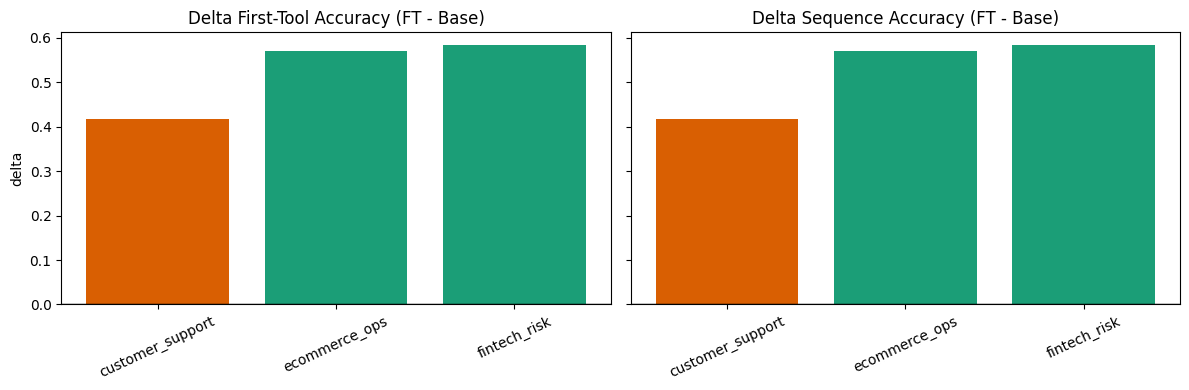

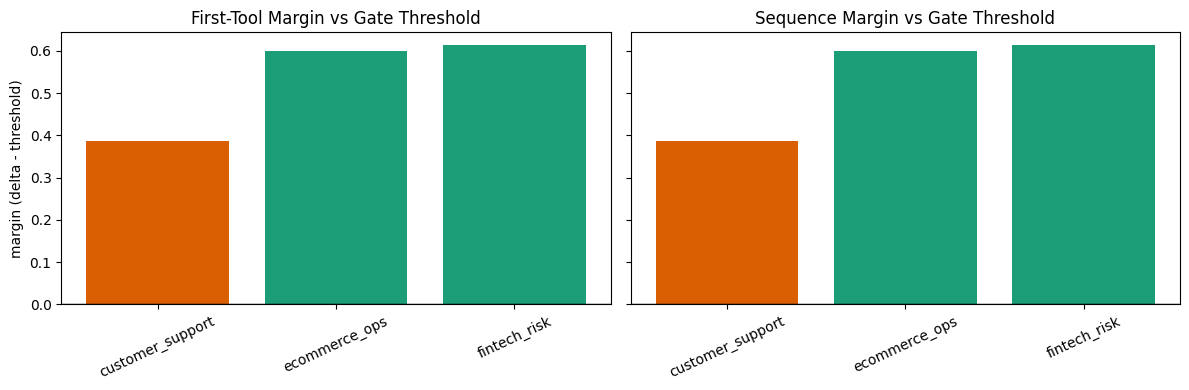

In [35]:
import matplotlib.pyplot as plt

if not MATRIX_JSON.exists():
    raise FileNotFoundError(
        f'Strict visualization requires matrix artifact at: {MATRIX_JSON}. '
        'Run the transfer matrix cell successfully first.'
    )

matrix_payload = json.loads(MATRIX_JSON.read_text(encoding='utf-8'))
matrix_rows = list(matrix_payload.get('rows', []))
if not matrix_rows:
    raise RuntimeError('Matrix JSON exists but contains no rows; cannot visualize.')

print('Matrix JSON:', MATRIX_JSON)
print('Matrix summary markdown:', MATRIX_MD)
print('Portfolio verdict:', matrix_payload.get('portfolio_verdict', 'unknown'))
print('Target toolset:', matrix_payload.get('target_toolset', 'unknown'))
print('Rows:', len(matrix_rows))

for row in matrix_rows:
    print(
        f"- {row.get('toolset_id')} ({row.get('split')}): "
        f"delta_first={float(row.get('delta_first_tool_accuracy', 0.0)):+.4f}, "
        f"delta_seq={float(row.get('delta_sequence_prefix_accuracy', 0.0)):+.4f}, "
        f"verdict={row.get('verdict')}"
    )

toolsets = [str(r.get('toolset_id', 'unknown')) for r in matrix_rows]
delta_first = [float(r.get('delta_first_tool_accuracy', 0.0)) for r in matrix_rows]
delta_seq = [float(r.get('delta_sequence_prefix_accuracy', 0.0)) for r in matrix_rows]
splits = [str(r.get('split', 'open')) for r in matrix_rows]

colors = ['#d95f02' if s == 'target' else '#1b9e77' for s in splits]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].bar(toolsets, delta_first, color=colors)
axes[0].axhline(0.0, color='black', linewidth=1.0)
axes[0].set_title('Delta First-Tool Accuracy (FT - Base)')
axes[0].set_ylabel('delta')
axes[0].tick_params(axis='x', rotation=25)

axes[1].bar(toolsets, delta_seq, color=colors)
axes[1].axhline(0.0, color='black', linewidth=1.0)
axes[1].set_title('Delta Sequence Accuracy (FT - Base)')
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()

thresholds = matrix_payload.get('thresholds', {})
target_first_thr = float(thresholds.get('target_first_tool_min_delta', 0.03))
target_seq_thr = float(thresholds.get('target_sequence_min_delta', 0.03))
open_first_thr = float(thresholds.get('open_first_tool_min_delta', -0.03))
open_seq_thr = float(thresholds.get('open_sequence_min_delta', -0.03))

first_margins = []
seq_margins = []
for row in matrix_rows:
    split = str(row.get('split', 'open'))
    d_first = float(row.get('delta_first_tool_accuracy', 0.0))
    d_seq = float(row.get('delta_sequence_prefix_accuracy', 0.0))
    if split == 'target':
        first_margins.append(d_first - target_first_thr)
        seq_margins.append(d_seq - target_seq_thr)
    else:
        first_margins.append(d_first - open_first_thr)
        seq_margins.append(d_seq - open_seq_thr)

fig2, axes2 = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
axes2[0].bar(toolsets, first_margins, color=colors)
axes2[0].axhline(0.0, color='black', linewidth=1.0)
axes2[0].set_title('First-Tool Margin vs Gate Threshold')
axes2[0].set_ylabel('margin (delta - threshold)')
axes2[0].tick_params(axis='x', rotation=25)

axes2[1].bar(toolsets, seq_margins, color=colors)
axes2[1].axhline(0.0, color='black', linewidth=1.0)
axes2[1].set_title('Sequence Margin vs Gate Threshold')
axes2[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()

## 8) HF-Only Kaggle Path (No Ollama Required For Core Experiments)

You can run the full base-vs-finetuned reliability loop entirely with Hugging Face inference on Kaggle GPU.

Use Ollama only when you want local serving convenience. It is not required for north-star metric generation.

In [ ]:
# Practical execution plan: HF-only on Kaggle for both base and finetuned inference/eval.

HF_NOTES = {
    'train_runtime': 'Kaggle T4 GPU',
    'finetune_type': 'QLoRA PEFT adapter-only (no full finetune)',
    'base_inference': 'HF model',
    'ft_inference': 'HF model + adapter',
    'strict_eval': True,
}

print('HF-only Kaggle flow:')
print('1) Run dataset build cells and QLoRA PEFT training cell on Kaggle T4.')
print('2) Run base and finetuned benchmark cells using HF planners.')
print('3) Run transfer-matrix cells for target/open generalization checks.')
print('4) Export artifacts under runs/<label>/ for reporting.')
print('\nHF experiment contract:')
print(json.dumps(HF_NOTES, indent=2))

USE_OLLAMA_FOR_EVAL = False

HF-only Kaggle flow (recommended for your setup):
1) Run dataset build cells and QLoRA PEFT training cell on Kaggle T4.
2) Keep base inference as Hugging Face base model in notebook benchmark cells.
3) Keep finetuned inference as Hugging Face base + saved adapter in notebook benchmark cells.
4) Run strict transfer-matrix cells for metric outputs and plots.
5) Export run artifacts under runs/<label>/ for reporting.

Optional local-only step (only if you need Ollama serving):
Create qwen3:4b-ft tag from downloaded adapter using scripts/create_ollama_adapter_tag.py.

HF experiment contract:
{
  "train_runtime": "Kaggle T4 GPU",
  "finetune_type": "QLoRA PEFT adapter-only (no full finetune)",
  "base_inference": "HF model",
  "ft_inference": "HF model + adapter",
  "strict_eval": true
}


In [15]:
# Runtime override for Kaggle-accessible base model and a short smoke budget.
MODEL_ID = 'Qwen/Qwen2.5-3B-Instruct'
MAX_STEPS = 60
print('MODEL_ID override:', MODEL_ID)
print('MAX_STEPS override:', MAX_STEPS)

MODEL_ID override: Qwen/Qwen2.5-3B-Instruct
MAX_STEPS override: 60


In [19]:
# Runtime auth (prompt-based): asks for HF and Kaggle credentials if not already set.
import os
from getpass import getpass

HF_TOKEN = str(os.environ.get('HF_TOKEN', '')).strip()
if not HF_TOKEN:
    HF_TOKEN = getpass('Enter HF_TOKEN (input hidden): ').strip()

if not HF_TOKEN:
    raise RuntimeError('HF_TOKEN is required for model downloads.')

os.environ['HF_TOKEN'] = HF_TOKEN
print('HF token configured for this runtime (value hidden).')

KAGGLE_USERNAME = str(os.environ.get('KAGGLE_USERNAME', '')).strip()
if not KAGGLE_USERNAME:
    KAGGLE_USERNAME = input('Enter KAGGLE_USERNAME: ').strip()

KAGGLE_KEY = str(os.environ.get('KAGGLE_KEY', '')).strip()
if not KAGGLE_KEY:
    # Supports users who store this as API token.
    KAGGLE_KEY = str(os.environ.get('KAGGLE_API_TOKEN', '')).strip()
if not KAGGLE_KEY:
    KAGGLE_KEY = getpass('Enter KAGGLE_KEY (input hidden): ').strip()

if KAGGLE_USERNAME and KAGGLE_KEY:
    os.environ['KAGGLE_USERNAME'] = KAGGLE_USERNAME
    os.environ['KAGGLE_KEY'] = KAGGLE_KEY
    print('Kaggle credentials configured for this runtime (values hidden).')
else:
    print('Kaggle credentials not fully set; publish/download cells may fail until provided.')

try:
    from huggingface_hub import login
    login(token=HF_TOKEN, add_to_git_credential=False)
    print('Hugging Face login succeeded for runtime session.')
except Exception as exc:
    print('Hugging Face login warning:', exc)
    print('Proceeding with token-only auth in model loaders.')

HF token configured for this runtime (value hidden).


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Kaggle credentials configured for this runtime (values hidden).
Hugging Face login succeeded for runtime session.


In [24]:
# Sync Kaggle clone with latest pushed GitHub changes.
sync_cmd = ['git', 'pull', '--ff-only', 'origin', 'main']
print('Running:', ' '.join(sync_cmd))
sync_res = subprocess.run(sync_cmd, text=True, capture_output=True, check=False)
if sync_res.stdout:
    print(sync_res.stdout)
if sync_res.returncode != 0:
    if sync_res.stderr:
        print(sync_res.stderr)
    raise RuntimeError(f'Git sync failed with code {sync_res.returncode}')
print('Repo sync complete at:', REPO_ROOT)

Running: git pull --ff-only origin main
Updating 0687fb5..6b37d38
Fast-forward
 .gitignore                                         |    1 +
 README.md                                          |  107 ++
 analysis/finetuning_entrypoint.ipynb               | 1458 ++++++++++++++++----
 configs/planners/finetuned_qwen2_5_3b_example.json |    8 +
 .../finetuned_qwen2_5_3b_strict_example.json       |    9 +
 .../planners/finetuned_qwen3_4b_strict_tag.json    |    9 +
 configs/planners/ollama_qwen2_5_3b.json            |    6 +
 configs/planners/ollama_qwen2_5_3b_strict.json     |    7 +
 configs/planners/ollama_qwen3_4b_strict.json       |    7 +
 models/ollama/Modelfile.qwen3-4b-ft-placeholder    |    3 +
 models/ollama/Modelfile.qwen3-4b-ft-test-script    |    3 +
 scripts/create_ollama_adapter_tag.py               |  102 ++
 scripts/generate_enriched_toolsets.py              |  272 ++++
 scripts/planners/ollama_tool_selector.py           |   20 +-
 scripts/run_transfer_matrix.py           

In [26]:
# Inspect planner configs available in synced repo.
planner_dir = REPO_ROOT / 'configs' / 'planners'
print('Planner configs:')
for p in sorted(planner_dir.glob('*.json')):
    print('-', p.name)

Planner configs:
- finetuned_example.json
- finetuned_qwen2_5_3b_example.json
- finetuned_qwen2_5_3b_strict_example.json
- finetuned_qwen3_4b_strict_tag.json
- heuristic.json
- ollama_gemma3_4b.json
- ollama_llama3_1_8b.json
- ollama_qwen2_5_3b.json
- ollama_qwen2_5_3b_strict.json
- ollama_qwen3_4b.json
- ollama_qwen3_4b_strict.json
- policy_native.json
- stochastic_lowhalluc.json
